In [1]:
# version9에서 RMSLE 계산법을 캐글과 동일하게 맞춘것 + 학습한 모델 저장 기능 추가

In [ ]:
"""
mercari_pycaret_analyzer9
--------------------------------
- Mercari Kaggle 경진용 가격 예측 파이프라인 (PyCaret 3.2.2 기준)
- version8 코드를 기반으로 정리/최적화한 버전입니다.

주요 특징
---------
1) 전처리 파이프라인
    - load_data  (언더샘플 옵션, 카테고리 split, rare 처리)
    - normalize_text
    - build_text_stats
    - build_price_brand_cat_features (SAFE 버전)
    - build_interactions
    - 각 단계별 stage_*.pkl 캐시 저장/로드 (version8과 호환)

2) 벡터화
    - TF-IDF (CPU, GPU 하이브리드)
    - BERT 임베딩 (CPU/GPU)
    - FastText, Word2Vec, GloVe
    - vectorized_{method}_train/test.pkl 캐시 저장/로드

3) 모델링 (PyCaret 3.2.2)
    - setup_pycaret
    - find_best_model : Kaggle RMSLE 기준으로 best model 선택
        * 후보: lightgbm, xgboost, catboost, et, rf, ridge
        * 필요시 목록 확장 가능
    - tune_best_model (옵션, Optuna)
    - save_best_model / load_saved_model

4) 평가/예측
    - save_metrics : Kaggle RMSLE 공식으로 계산
        * R2, RMSE, MAE, RMSLE_kaggle
        * 이미 저장된 모델만 로드해도, 캐시된 train / vectorized 를 찾아서 자동 복구 시도
    - predict_test : submission.csv 생성

주의
----
- 감성 분석( Sentiment )은 제거했습니다. (요청사항 반영)
- version8에서 생성된 stage_*.pkl, vectorized_*.pkl, preprocessed_*.pkl 를 그대로 재사용 가능하도록 경로/형식 유지.
- PyCaret 3.2.2 에 맞춰서 fold_predictions, custom_metrics 사용은 하지 않고
  train 전체 예측 기반 + Kaggle RMSLE 공식으로 일관되게 계산합니다.
"""

# ----------------------------
# 기본 임포트
# ----------------------------
import os
import re
import gc
import json
import pickle
import hashlib
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from tqdm import tqdm
from pathlib import Path
from datetime import datetime

# ML / NLP
import torch

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA

# optional imports
try:
    from sentence_transformers import SentenceTransformer
except Exception:
    SentenceTransformer = None

try:
    from gensim.models import FastText, Word2Vec
except Exception:
    FastText = None
    Word2Vec = None

# PyCaret 회귀
try:
    from pycaret.regression import (
        setup,
        create_model,
        compare_models,
        tune_model,
        save_model,
        load_model,
        predict_model,
        pull,
    )
except Exception:
    setup = create_model = compare_models = tune_model = None
    save_model = load_model = predict_model = pull = None


# ======================================================================
# ===================== CLASS: MercariPyCaretAnalyzer9 ==================
# ======================================================================


class MercariPyCaretAnalyzer9:
    """
    =========================================================================
    MercariPyCaretAnalyzer9 클래스
    =========================================================================
    개요:
        Mercari(또는 유사 전자상거래) 상품 가격 예측을 위해 설계한
        PyCaret 3.2.2 기반 엔드-투-엔드 파이프라인 클래스입니다.

    주요 기능:
        - 데이터 로딩 및 전처리 (category 분해, rare 처리, 언더샘플)
        - 텍스트 정규화 및 텍스트 통계 피처 생성
        - 가격-브랜드-카테고리 통계 SAFE 피처
        - 상호작용 피처- 다양한 텍스트 벡터화 (TF-IDF, BERT, FastText, Word2Vec, GloVe)
        - PyCaret setup / 모델 탐색 / 튜닝 / 저장 / 로드
        - Kaggle RMSLE 공식 기반의 일관된 성능 평가
        - Stage 기반 캐시, 벡터화 캐시를 통한 재실행 시간 단축

    특징:
        - 감성분석은 제외(요청사항).
        - version8에서 생성한 pkl(stage_*, vectorized_*, preprocessed_*) 재사용 가능.
        - 이미 저장된 모델(pkl)을 나중에 불러와서 save_metrics()만 단독 실행 가능하도록
          내부에서 train / train_vectorized 를 캐시에서 자동 복원 시도.
    =========================================================================
    """

    # [__init__] start #########################################################
    def __init__(
        self,
        data_dir="../data",
        images_dir="../images",
        results_dir="../results",
        model_dir="../models",
        use_gpu=True,
    ):
        """
        클래스 초기화

        Parameters
        ----------
        data_dir : str
            train.tsv / test.tsv 위치 폴더
        images_dir : str
            시각화 이미지 저장 폴더
        results_dir : str
            전처리/결과/캐시(pkl, submission, metrics 등) 저장 폴더
        model_dir : str
            모델 및 벡터화 결과 저장 폴더
        use_gpu : bool
            GPU 사용 여부 (벡터화/모델에서 가능한 경우)
        """
        self.data_dir = data_dir
        self.images_dir = images_dir
        self.results_dir = results_dir
        self.model_dir = model_dir
        self.use_gpu = use_gpu

        # 디바이스 탐지
        self.device = None
        self._detect_device()

        # 데이터프레임
        self.train = None
        self.test = None

        # 벡터화된 데이터
        self.train_vectorized = None
        self.test_vectorized = None

        # PyCaret 관련
        self.setup_result = None
        self.best_model = None
        self.metrics = {}
        self.models = {}

        # 디렉토리 생성
        os.makedirs(self.images_dir, exist_ok=True)
        os.makedirs(self.results_dir, exist_ok=True)
        os.makedirs(self.model_dir, exist_ok=True)

    # [__init__] end ===========================================================

    # [_detect_device] start ####################################################
    def _detect_device(self):
        """
        내부용 - 사용 가능한 디바이스를 탐지합니다.
        - self.use_gpu=True & torch.cuda.is_available() 이면 'cuda'
        - 아니면 'cpu'
        """
        device = "cpu"
        try:
            if self.use_gpu and torch.cuda.is_available():
                device = "cuda"
        except Exception:
            device = "cpu"
        self.device = device
        return self.device

    # [_detect_device] end =====================================================

    # [load_data] start #########################################################
    def load_data(
        self,
        train_file="train.tsv",
        test_file="test.tsv",
        sep="\t",
        undersample_frac=None,
    ):
        """
        데이터 로딩 및 기본 전처리

        주요 처리:
            - train/test 로드
            - price > 0 필터 후 log1p(price)로 변환 (train)
            - category_name -> main_cat / sub_cat / sub_sub_cat 분리
            - brand_name / item_description / name 결측 처리
            - 희귀값 통합 (brand, category)
            - (옵션) stratified undersample
        """
        print("📂 데이터 로딩 시작...")

        train_path = os.path.join(self.data_dir, train_file)
        test_path = os.path.join(self.data_dir, test_file)

        self.train = pd.read_csv(train_path, sep=sep)
        self.test = pd.read_csv(test_path, sep=sep)

        # price 전처리
        self.train = (
            self.train[self.train["price"] > 0]
            .dropna(subset=["price"])
            .reset_index(drop=True)
        )
        self.train["price"] = np.log1p(self.train["price"])

        # category split 및 기본 fill
        for df in [self.train, self.test]:
            df["category_name"] = df.get("category_name", "").fillna("missing")

            def _split_cat(x):
                parts = x.split("/") if isinstance(x, str) else ["missing"] * 3
                while len(parts) < 3:
                    parts.append("missing")
                return parts[:3]

            df["main_cat"], df["sub_cat"], df["sub_sub_cat"] = zip(
                *df["category_name"].apply(_split_cat)
            )

            df["brand_name"] = df["brand_name"].fillna("Unknown").astype(str)
            df["item_description"] = (
                df["item_description"].fillna("No description").astype(str)
            )
            df["name"] = df["name"].fillna("No name").astype(str)

            if "shipping" in df.columns:
                df["shipping"] = df["shipping"].astype("category")
            if "item_condition_id" in df.columns:
                df["item_condition_id"] = df["item_condition_id"].astype("category")

        print("🔄 희귀값 통합 중...")
        self._collapse_rare_values("brand_name", top_k=5000, rare_label="Other_brand")
        self._collapse_rare_values("main_cat", top_k=1000, rare_label="Other_main")
        self._collapse_rare_values("sub_cat", top_k=1000, rare_label="Other_sub")
        self._collapse_rare_values(
            "sub_sub_cat", top_k=1000, rare_label="Other_sub_sub"
        )

        if undersample_frac:
            self._stratified_sample(frac=undersample_frac)

        if "price" not in self.train.columns:
            raise RuntimeError("❌ load_data 이후 price 컬럼이 누락되었습니다.")

        print(f"✅ 데이터 로딩 완료: train {self.train.shape}, test {self.test.shape}")

    # [load_data] end ==========================================================

    # [_collapse_rare_values] start ############################################
    def _collapse_rare_values(self, col, top_k, rare_label="Other"):
        """
        상위 top_k 값을 제외한 나머지를 rare_label로 대체 (train/test 병합 기준)
        """
        combined = pd.concat([self.train[col], self.test[col]], axis=0)
        value_counts = combined.value_counts()
        top_values = set(value_counts.index[:top_k])

        self.train[col] = self.train[col].apply(
            lambda x: x if x in top_values else rare_label
        )
        self.test[col] = self.test[col].apply(
            lambda x: x if x in top_values else rare_label
        )

        del combined, value_counts
        gc.collect()

    # [_collapse_rare_values] end ==============================================

    # [_stratified_sample] start ###############################################
    def _stratified_sample(self, frac=0.35, bins=10):
        """
        price를 기준으로 qcut-binning 후 계층적(층화) 언더샘플
        """
        print("⚠️ Stratified undersampling 수행...")
        df = self.train.copy()
        df["price_bin"] = pd.qcut(df["price"], q=bins, duplicates="drop")
        sampled = (
            df.groupby("price_bin", group_keys=False, observed=True)
            .apply(lambda x: x.sample(frac=frac, random_state=23))
            .reset_index(drop=True)
        )
        sampled.drop(columns=["price_bin"], inplace=True)
        self.train = sampled
        print(f"👉 언더샘플 적용 후 train: {self.train.shape}")

    # [_stratified_sample] end ================================================

    # [normalize_text] start ####################################################
    def normalize_text(
        self,
        cols=["name", "item_description"],
        lower=True,
        strip_punct=True,
        numbers_to_token=True,
    ):
        """
        텍스트 정규화: *_norm 컬럼으로 저장
        - 소문자 변환, 특수문자 제거, 숫자 -> 'num' 토큰
        """
        print("🧼 텍스트 정규화 시작...")

        def _norm(text):
            t = str(text)
            if lower:
                t = t.lower()
            if strip_punct:
                t = re.sub(r"[^a-zA-Z0-9\s]", " ", t)
            if numbers_to_token:
                t = re.sub(r"\d+", " num ", t)
            return re.sub(r"\s+", " ", t).strip()

        for df in [self.train, self.test]:
            for c in cols:
                df[f"{c}_norm"] = df[c].astype(str).apply(_norm)

        print("✅ 텍스트 정규화 완료")

    # [normalize_text] end =====================================================

    # [build_text_stats] start #################################################
    def build_text_stats(self, cols=["name", "item_description"]):
        """
        텍스트 기반 통계 피처 생성
        - 토큰 수, 고유 토큰 수, 평균 단어 길이
        - 대문자 비율, 숫자 비율, 문장부호 비율
        - name/description 길이 비율 등
        """
        print("📈 텍스트 통계 피처 생성 중...")

        def _stats(s):
            s = str(s)
            tokens = s.split()
            token_count = len(tokens)
            uniq = len(set(tokens))
            avg_word_len = np.mean([len(w) for w in tokens]) if tokens else 0.0
            upper_ratio = sum(1 for ch in s if ch.isupper()) / max(1, len(s))
            digit_ratio = sum(1 for ch in s if ch.isdigit()) / max(1, len(s))
            punct_ratio = sum(1 for ch in s if re.match(r"[^\w\s]", ch)) / max(
                1, len(s)
            )
            return (
                token_count,
                uniq,
                avg_word_len,
                upper_ratio,
                digit_ratio,
                punct_ratio,
            )

        for base in cols:
            for df in [self.train, self.test]:
                arr = df[base].astype(str).apply(_stats).tolist()
                tok, uniq, avgw, upr, dr, pr = zip(*arr)
                df[f"{base}_tok_count"] = tok
                df[f"{base}_uniq_tok"] = uniq
                df[f"{base}_avg_word_len"] = avgw
                df[f"{base}_upper_ratio"] = upr
                df[f"{base}_digit_ratio"] = dr
                df[f"{base}_punct_ratio"] = pr

        for df in [self.train, self.test]:
            df["name_len_char"] = df["name"].astype(str).str.len()
            df["name_len_word"] = df["name"].astype(str).str.split().str.len()
            df["desc_len_char"] = df["item_description"].astype(str).str.len()
            df["desc_len_word"] = (
                df["item_description"].astype(str).str.split().str.len()
            )
            df["desc_name_char_ratio"] = (
                (df["desc_len_char"] / df["name_len_char"])
                .replace([np.inf, -np.inf], 0)
                .fillna(0)
            )
            df["desc_name_word_ratio"] = (
                (df["desc_len_word"] / df["name_len_word"])
                .replace([np.inf, -np.inf], 0)
                .fillna(0)
            )

            # 브랜드 포함 여부 플래그
            df["has_brand_in_name"] = df.apply(
                lambda r: (
                    1 if str(r["brand_name"]).lower() in str(r["name"]).lower() else 0
                ),
                axis=1,
            )
            df["has_brand_in_desc"] = df.apply(
                lambda r: (
                    1
                    if str(r["brand_name"]).lower()
                    in str(r["item_description"]).lower()
                    else 0
                ),
                axis=1,
            )

        print("✅ 텍스트 통계 피처 생성 완료")

    # [build_text_stats] end ===================================================

    # [build_price_brand_cat_features] start ###################################
    def build_price_brand_cat_features(
        self,
        price_col="price",
        brand_col="brand_name",
        cat_cols=["main_cat", "sub_cat", "sub_sub_cat"],
        rare_thresh_brand=20,
        rare_thresh_cat=20,
    ):
        """
        가격-브랜드-카테고리 기반 통계 피처 (SAFE 버전)

        - train 에서만 price를 사용하여 그룹 통계(mean/median/std) 산출
        - train/test 에 같은 통계를 join
        - brand_price_z (train만, test는 0)
        - rare_brand / rare_{cat} 플래그
        - brand_in_name_ratio / brand_in_desc_ratio
        """
        print("\n=== SAFE VERSION: build_price_brand_cat_features ===")

        if price_col not in self.train.columns:
            raise RuntimeError("❌ train 데이터에 price가 없습니다.")

        grp_cols = [brand_col] + cat_cols

        # 1) 그룹 통계
        for col in grp_cols:
            print(f"📊 building stats for '{col}' ...")
            stats = (
                self.train.groupby(col)[price_col]
                .agg(["mean", "median", "std"])
                .rename(
                    columns={
                        "mean": f"{col}_price_mean",
                        "median": f"{col}_price_median",
                        "std": f"{col}_price_std",
                    }
                )
            )

            self.train = self.train.join(stats, on=col)
            self.test = self.test.join(stats, on=col)

            for df in [self.train, self.test]:
                for cc in [
                    f"{col}_price_mean",
                    f"{col}_price_median",
                    f"{col}_price_std",
                ]:
                    if cc in df.columns:
                        df[cc] = df[cc].fillna(0)

        # 2) train brand_price_z
        print("⚖️ computing z-score ...")
        mu_train = self.train[f"{brand_col}_price_mean"]
        sd_train = self.train[f"{brand_col}_price_std"].replace(0, 1)

        self.train["brand_price_z"] = (
            ((self.train[price_col] - mu_train) / sd_train)
            .replace([np.inf, -np.inf], 0)
            .fillna(0)
        )

        # test 는 price가 없으므로 0으로 채우기
        self.test["brand_price_z"] = 0.0

        # 3) rare flags
        brand_freq = self.train[brand_col].value_counts()
        cat_freqs = {c: self.train[c].value_counts() for c in cat_cols}

        for df_name in ["train", "test"]:
            df = getattr(self, df_name)
            df["rare_brand"] = df[brand_col].apply(
                lambda x: int(brand_freq.get(x, 0) < rare_thresh_brand)
            )
            for c in cat_cols:
                df[f"rare_{c}"] = df[c].apply(
                    lambda x: int(cat_freqs[c].get(x, 0) < rare_thresh_cat)
                )
            setattr(self, df_name, df)

        # 4) brand in text (ratio 라기보다는 binary flag)
        def _brand_in_field(row, bcol, fcol):
            b = str(row[bcol]).lower()
            f = str(row[fcol]).lower()
            return int(b != "" and b in f)

        for df_name in ["train", "test"]:
            df = getattr(self, df_name)
            df["brand_in_name_ratio"] = df.apply(
                lambda r: _brand_in_field(r, brand_col, "name"),
                axis=1,
            )
            df["brand_in_desc_ratio"] = df.apply(
                lambda r: _brand_in_field(r, brand_col, "item_description"),
                axis=1,
            )
            setattr(self, df_name, df)

        print("✅ SAFE price-brand-category feature creation DONE.")

    # [build_price_brand_cat_features] end =====================================

    # [build_interactions] start ###############################################
    def build_interactions(
        self,
        pairs=[("item_condition_id", "shipping"), ("brand_name", "main_cat")],
    ):
        """
        상호작용 피처 생성
        - pairs: (colA, colB) 튜플 리스트
        """
        print("🔗 상호작용 피처 생성 중...")
        for a, b in pairs:
            colname = f"{a}__x__{b}"
            for df in [self.train, self.test]:
                if a in df.columns and b in df.columns:
                    df[colname] = df[a].astype(str) + "_" + df[b].astype(str)
        print("✅ 상호작용 피처 생성 완료")

    # [build_interactions] end ================================================

    # [vectorize_text_tfidf] start #############################################
    def vectorize_text_tfidf(
        self,
        max_features_name=15000,
        max_features_desc=20000,
        n_components=150,
    ):
        """
        TF-IDF 기반 벡터화 및 TruncatedSVD 차원 축소 (CPU)
        - name / item_description 각각 처리
        """
        print("🔍 TF-IDF 벡터화 시작 (CPU)...")

        vec_name = TfidfVectorizer(
            max_features=max_features_name,
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.95,
            sublinear_tf=True,
            dtype=np.float32,
        )
        Xn_train = vec_name.fit_transform(self.train["name"].astype(str))
        Xn_test = vec_name.transform(self.test["name"].astype(str))

        n_comp_name = max(1, min(n_components, Xn_train.shape[1] - 1))
        svd_name = TruncatedSVD(n_components=n_comp_name, random_state=23)
        name_train_svd = svd_name.fit_transform(Xn_train)
        name_test_svd = svd_name.transform(Xn_test)

        del Xn_train, Xn_test
        gc.collect()

        vec_desc = TfidfVectorizer(
            max_features=max_features_desc,
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.95,
            sublinear_tf=True,
            dtype=np.float32,
        )
        Xd_train = vec_desc.fit_transform(self.train["item_description"].astype(str))
        Xd_test = vec_desc.transform(self.test["item_description"].astype(str))

        n_comp_desc = max(1, min(n_components, Xd_train.shape[1] - 1))
        svd_desc = TruncatedSVD(n_components=n_comp_desc, random_state=23)
        desc_train_svd = svd_desc.fit_transform(Xd_train)
        desc_test_svd = svd_desc.transform(Xd_test)

        del Xd_train, Xd_test
        gc.collect()

        train_vec = np.hstack([name_train_svd, desc_train_svd]).astype(np.float32)
        test_vec = np.hstack([name_test_svd, desc_test_svd]).astype(np.float32)

        name_cols = [f"name_{i}" for i in range(n_comp_name)]
        desc_cols = [f"desc_{i}" for i in range(n_comp_desc)]
        cols = name_cols + desc_cols

        self.train_vectorized = pd.DataFrame(train_vec, columns=cols)
        self.test_vectorized = pd.DataFrame(test_vec, columns=cols)

        self._add_categorical_numeric_features()
        print(
            f"✅ TF-IDF 벡터화 완료: train {self.train_vectorized.shape}, "
            f"test {self.test_vectorized.shape}"
        )

    # [vectorize_text_tfidf] end ==============================================

    # [vectorize_text_tfidf_gpu] start #########################################
    def vectorize_text_tfidf_gpu(
        self,
        max_features_name=15000,
        max_features_desc=20000,
        n_components=150,
    ):
        """
        TF-IDF는 CPU에서 계산, SVD는 가능하면 cuML로 GPU에서 가속.
        - cuML / cupy 사용 불가 시 sklearn TruncatedSVD로 fallback.
        """
        print("🔍 TF-IDF + (가능 시) GPU SVD 시작...")

        # 1) TF-IDF (CPU)
        vec_name = TfidfVectorizer(
            max_features=max_features_name,
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.95,
            sublinear_tf=True,
            dtype=np.float32,
        )
        Xn_train = vec_name.fit_transform(self.train["name"].astype(str))
        Xn_test = vec_name.transform(self.test["name"].astype(str))

        vec_desc = TfidfVectorizer(
            max_features=max_features_desc,
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.95,
            sublinear_tf=True,
            dtype=np.float32,
        )
        Xd_train = vec_desc.fit_transform(self.train["item_description"].astype(str))
        Xd_test = vec_desc.transform(self.test["item_description"].astype(str))

        from scipy.sparse import hstack as sp_hstack

        X_train = sp_hstack([Xn_train, Xd_train]).tocsr()
        X_test = sp_hstack([Xn_test, Xd_test]).tocsr()

        # 2) GPU SVD (옵션)
        use_gpu_svd = False
        try:
            import cupy as cp
            from cupyx.scipy.sparse import csr_matrix as cupy_csr
            from cuml.decomposition import TruncatedSVD as cumlTruncatedSVD

            use_gpu_svd = True
        except Exception:
            use_gpu_svd = False

        if use_gpu_svd:
            print("   - cuML 사용 가능: GPU에서 TruncatedSVD 수행")
            X_train_gpu = cupy_csr(X_train)
            X_test_gpu = cupy_csr(X_test)
            n_comp = max(1, min(n_components, X_train.shape[1] - 1))
            svd_gpu = cumlTruncatedSVD(n_components=n_comp, random_state=23)
            train_vec_gpu = svd_gpu.fit_transform(X_train_gpu)
            test_vec_gpu = svd_gpu.transform(X_test_gpu)
            train_vec = cp.asnumpy(train_vec_gpu).astype(np.float32)
            test_vec = cp.asnumpy(test_vec_gpu).astype(np.float32)
        else:
            print("   - cuML 미사용: CPU에서 sklearn TruncatedSVD 실행")
            from sklearn.decomposition import TruncatedSVD as sklSVD

            n_comp = max(1, min(n_components, X_train.shape[1] - 1))
            svd = sklSVD(n_components=n_comp, random_state=23)
            train_vec = svd.fit_transform(X_train)
            test_vec = svd.transform(X_test)

        final_dim = train_vec.shape[1]
        cols = [f"tfidf_svd_{i}" for i in range(final_dim)]

        self.train_vectorized = pd.DataFrame(train_vec, columns=cols)
        self.test_vectorized = pd.DataFrame(test_vec, columns=cols)

        self._add_categorical_numeric_features()
        print(
            f"✅ TF-IDF + SVD 완료: train {self.train_vectorized.shape}, "
            f"test {self.test_vectorized.shape}"
        )

    # [vectorize_text_tfidf_gpu] end ==========================================

    # [vectorize_text_bert] start ##############################################
    def vectorize_text_bert(
        self,
        text_columns=["name", "item_description"],
        bert_model_name="all-MiniLM-L6-v2",
        batch_size=64,
    ):
        """
        BERT(SentenceTransformer) 기반 문장 임베딩 (CPU/기본 device)
        """
        if SentenceTransformer is None:
            raise RuntimeError("sentence_transformers가 설치되어 있지 않습니다.")
        print(f"🔍 BERT 벡터화 시작 (model={bert_model_name}, device=cpu/default)")

        model = SentenceTransformer(bert_model_name)
        train_feats = []
        test_feats = []

        for col in text_columns:
            self.train[col] = self.train[col].fillna("").astype(str)
            self.test[col] = self.test[col].fillna("").astype(str)

            print(f"   - 임베딩 컬럼: {col}")
            emb_train = model.encode(
                self.train[col].tolist(),
                batch_size=batch_size,
                show_progress_bar=True,
            )
            emb_test = model.encode(
                self.test[col].tolist(),
                batch_size=batch_size,
                show_progress_bar=True,
            )
            train_feats.append(np.asarray(emb_train, dtype=np.float32))
            test_feats.append(np.asarray(emb_test, dtype=np.float32))

        train_vec = np.hstack(train_feats).astype(np.float32)
        test_vec = np.hstack(test_feats).astype(np.float32)

        dim_each = train_feats[0].shape[1]
        cols = [f"{col}_bert_{i}" for col in text_columns for i in range(dim_each)]

        self.train_vectorized = pd.DataFrame(train_vec, columns=cols)
        self.test_vectorized = pd.DataFrame(test_vec, columns=cols)

        self._add_categorical_numeric_features()
        print("✅ BERT 벡터화 완료")

    # [vectorize_text_bert] end ===============================================

    # [vectorize_text_bert_gpu] start ##########################################
    def vectorize_text_bert_gpu(
        self,
        text_columns=["name", "item_description"],
        bert_model_name="all-MiniLM-L6-v2",
        batch_size=128,
    ):
        """
        GPU 사용 SentenceTransformer 기반 BERT 임베딩
        - self.device 를 사용 (cuda/cpu)
        """
        print("🔍 [GPU] BERT 임베딩 시작...")

        if SentenceTransformer is None:
            raise RuntimeError("sentence_transformers가 설치되어 있지 않습니다.")

        if not hasattr(self, "device"):
            self._detect_device()

        device = getattr(self, "device", "cpu")

        try:
            model = SentenceTransformer(bert_model_name, device=device)
        except Exception as e:
            print(f"⚠️ GPU 로딩 실패 ({e}) → CPU로 재시도")
            model = SentenceTransformer(bert_model_name, device="cpu")
            device = "cpu"

        train_feats = []
        test_feats = []

        for col in text_columns:
            self.train[col] = self.train[col].fillna("").astype(str)
            self.test[col] = self.test[col].fillna("").astype(str)

            print(f"   - 임베딩 컬럼: {col} (device={device})")
            emb_train = model.encode(
                self.train[col].tolist(),
                batch_size=batch_size,
                show_progress_bar=True,
                device=device,
            )
            emb_test = model.encode(
                self.test[col].tolist(),
                batch_size=batch_size,
                show_progress_bar=True,
                device=device,
            )
            train_feats.append(np.asarray(emb_train, dtype=np.float32))
            test_feats.append(np.asarray(emb_test, dtype=np.float32))

        train_vec = np.hstack(train_feats).astype(np.float32)
        test_vec = np.hstack(test_feats).astype(np.float32)

        dim_each = train_feats[0].shape[1]
        cols = [f"{col}_bert_{i}" for col in text_columns for i in range(dim_each)]

        self.train_vectorized = pd.DataFrame(train_vec, columns=cols)
        self.test_vectorized = pd.DataFrame(test_vec, columns=cols)

        self._add_categorical_numeric_features()
        print(
            f"✅ [GPU] BERT 임베딩 완료: train {self.train_vectorized.shape}, "
            f"test {self.test_vectorized.shape}"
        )

    # [vectorize_text_bert_gpu] end ===========================================

    # [vectorize_text_fasttext] start ##########################################
    def vectorize_text_fasttext(
        self,
        text_columns=["name", "item_description"],
        fasttext_size=100,
        fasttext_window=5,
        fasttext_min_count=2,
        n_components=None,
    ):
        """
        FastText 학습 후 평균 pooling으로 문장 벡터 생성
        """
        if FastText is None:
            raise RuntimeError("gensim FastText가 설치되어 있지 않습니다.")
        print("🔍 FastText 학습 시작...")

        sentences = []
        for col in text_columns:
            sentences += [
                s.split()
                for s in pd.concat([self.train[col], self.test[col]]).astype(str)
            ]

        ft = FastText(
            sentences,
            vector_size=fasttext_size,
            window=fasttext_window,
            min_count=fasttext_min_count,
            sg=1,
            workers=4,
        )

        def _vec(text):
            words = str(text).split()
            vecs = [ft.wv[w] for w in words if w in ft.wv]
            return np.mean(vecs, axis=0) if vecs else np.zeros(fasttext_size)

        train_feats = []
        test_feats = []

        for col in tqdm(text_columns, desc="FastText Vectorizing"):
            train_feats.append(np.vstack(self.train[col].astype(str).apply(_vec)))
            test_feats.append(np.vstack(self.test[col].astype(str).apply(_vec)))

        train_vec = np.hstack(train_feats).astype(np.float32)
        test_vec = np.hstack(test_feats).astype(np.float32)

        if n_components:
            pca = PCA(n_components=n_components, random_state=42)
            train_vec = pca.fit_transform(train_vec)
            test_vec = pca.transform(test_vec)

        dim = train_vec.shape[1] // len(text_columns)
        cols = [f"{col}_ft_{i}" for col in text_columns for i in range(dim)]

        self.train_vectorized = pd.DataFrame(train_vec, columns=cols)
        self.test_vectorized = pd.DataFrame(test_vec, columns=cols)

        self._add_categorical_numeric_features()
        print("✅ FastText 벡터화 완료")

    # [vectorize_text_fasttext] end ===========================================

    # [vectorize_text_word2vec] start ##########################################
    def vectorize_text_word2vec(
        self,
        text_columns=["name", "item_description"],
        w2v_size=100,
        w2v_window=5,
        w2v_min_count=2,
        n_components=None,
    ):
        """
        Word2Vec 학습 후 평균 pooling으로 문장 벡터 생성
        """
        if Word2Vec is None:
            raise RuntimeError("gensim Word2Vec가 설치되어 있지 않습니다.")
        print("🔍 Word2Vec 학습 시작...")

        sentences = []
        for col in text_columns:
            sentences += [
                s.split()
                for s in pd.concat([self.train[col], self.test[col]]).astype(str)
            ]

        w2v = Word2Vec(
            sentences,
            vector_size=w2v_size,
            window=w2v_window,
            min_count=w2v_min_count,
            sg=1,
            workers=4,
        )

        def _vec(text):
            words = str(text).split()
            vecs = [w2v.wv[w] for w in words if w in w2v.wv]
            return np.mean(vecs, axis=0) if vecs else np.zeros(w2v_size)

        train_feats = []
        test_feats = []

        for col in tqdm(text_columns, desc="Word2Vec Vectorizing"):
            train_feats.append(np.vstack(self.train[col].astype(str).apply(_vec)))
            test_feats.append(np.vstack(self.test[col].astype(str).apply(_vec)))

        train_vec = np.hstack(train_feats).astype(np.float32)
        test_vec = np.hstack(test_feats).astype(np.float32)

        if n_components:
            pca = PCA(n_components=n_components, random_state=42)
            train_vec = pca.fit_transform(train_vec)
            test_vec = pca.transform(test_vec)

        dim = train_vec.shape[1] // len(text_columns)
        cols = [f"{col}_w2v_{i}" for col in text_columns for i in range(dim)]

        self.train_vectorized = pd.DataFrame(train_vec, columns=cols)
        self.test_vectorized = pd.DataFrame(test_vec, columns=cols)

        self._add_categorical_numeric_features()
        print("✅ Word2Vec 벡터화 완료")

    # [vectorize_text_word2vec] end ===========================================

    # [vectorize_text_glove] start #############################################
    def vectorize_text_glove(
        self,
        text_columns=["name", "item_description"],
        glove_path="./data/glove.6B.100d.txt",
        n_components=None,
    ):
        """
        GloVe 사전학습 벡터 로드 후 평균 pooling
        """
        print("🔍 GloVe 로드 시작...")

        embeddings = {}
        dim = None
        with open(glove_path, encoding="utf8") as f:
            for line in f:
                parts = line.split()
                word = parts[0]
                vec = np.asarray(parts[1:], dtype=np.float32)
                embeddings[word] = vec
                if dim is None:
                    dim = len(vec)

        if dim is None:
            raise ValueError("GloVe 로드 실패: 파일 경로/형식 확인")

        def _vec(text):
            words = str(text).split()
            vecs = [embeddings[w] for w in words if w in embeddings]
            return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

        train_feats = []
        test_feats = []

        for col in tqdm(text_columns, desc="GloVe Vectorizing"):
            train_feats.append(np.vstack(self.train[col].astype(str).apply(_vec)))
            test_feats.append(np.vstack(self.test[col].astype(str).apply(_vec)))

        train_vec = np.hstack(train_feats).astype(np.float32)
        test_vec = np.hstack(test_feats).astype(np.float32)

        if n_components:
            pca = PCA(n_components=n_components, random_state=42)
            train_vec = pca.fit_transform(train_vec)
            test_vec = pca.transform(test_vec)

        dim = train_vec.shape[1] // len(text_columns)
        cols = [f"{col}_glove_{i}" for col in text_columns for i in range(dim)]

        self.train_vectorized = pd.DataFrame(train_vec, columns=cols)
        self.test_vectorized = pd.DataFrame(test_vec, columns=cols)

        self._add_categorical_numeric_features()
        print("✅ GloVe 벡터화 완료")

    # [vectorize_text_glove] end ==============================================

    # [_add_categorical_numeric_features] start ################################
    def _add_categorical_numeric_features(self):
        """
        벡터화된 dataframe에 기존 구조적(범주형/수치형) 피처를 결합.
        - 감성 분석 관련 피처는 제외됨.
        """
        print("📌 구조적/수치형 피처를 벡터화 프레임에 결합 중...")

        categorical_features = [
            "main_cat",
            "sub_cat",
            "sub_sub_cat",
            "brand_name",
            "item_condition_id",
            "shipping",
            "item_condition_id__x__shipping",
            "brand_name__x__main_cat",
        ]

        numeric_features = [
            # text stats
            "name_tok_count",
            "name_uniq_tok",
            "name_avg_word_len",
            "name_upper_ratio",
            "name_digit_ratio",
            "name_punct_ratio",
            "item_description_tok_count",
            "item_description_uniq_tok",
            "item_description_avg_word_len",
            "item_description_upper_ratio",
            "item_description_digit_ratio",
            "item_description_punct_ratio",
            "name_len_char",
            "name_len_word",
            "desc_len_char",
            "desc_len_word",
            "desc_name_char_ratio",
            "desc_name_word_ratio",
            "has_brand_in_name",
            "has_brand_in_desc",
            # price-brand-cat
            "brand_name_price_mean",
            "brand_name_price_median",
            "brand_name_price_std",
            "brand_price_z",
            "rare_brand",
            "main_cat_price_mean",
            "main_cat_price_median",
            "main_cat_price_std",
            "rare_main_cat",
            "sub_cat_price_mean",
            "sub_cat_price_median",
            "sub_cat_price_std",
            "rare_sub_cat",
            "sub_sub_cat_price_mean",
            "sub_sub_cat_price_median",
            "sub_sub_cat_price_std",
            "rare_sub_sub_cat",
            "brand_in_name_ratio",
            "brand_in_desc_ratio",
        ]

        for col in categorical_features + numeric_features:
            if col in self.train.columns:
                self.train_vectorized[col] = self.train[col].reset_index(drop=True)
                self.test_vectorized[col] = self.test[col].reset_index(drop=True)

        print(
            f"👍 결합 완료: train {self.train_vectorized.shape}, "
            f"test {self.test_vectorized.shape}"
        )

    # [_add_categorical_numeric_features] end ================================

    # [vectorize_text] start ###################################################
    def vectorize_text(self, method="tfidf", **kwargs):
        """
        텍스트 벡터화 통합 인터페이스
        - method: "tfidf","fasttext","bert","word2vec","glove"
        - use_gpu=True 이면 GPU 전용 메서드 우선 사용, 실패 시 CPU fallback
        - 캐시가 있다면 vectorized_{method}_*.pkl 로부터 로드
        """
        m = method.lower()

        # 1) 캐시 먼저 확인
        if self.load_vectorized(m):
            return

        use_gpu = getattr(self, "use_gpu", False)

        gpu_methods = {
            "tfidf": "vectorize_text_tfidf_gpu",
            "bert": "vectorize_text_bert_gpu",
        }

        cpu_methods = {
            "tfidf": "vectorize_text_tfidf",
            "fasttext": "vectorize_text_fasttext",
            "bert": "vectorize_text_bert",
            "word2vec": "vectorize_text_word2vec",
            "glove": "vectorize_text_glove",
        }

        if use_gpu and m in gpu_methods:
            gpu_func_name = gpu_methods[m]
            gpu_func = getattr(self, gpu_func_name, None)
            if gpu_func is not None:
                try:
                    print(f"⚡ GPU 벡터화 실행: {gpu_func_name}()")
                    gpu_func(**kwargs)
                    self.save_vectorized(m)
                    return
                except Exception as e:
                    print(f"⚠️ GPU 벡터화 실패 → CPU fallback: {e}")

        if m not in cpu_methods:
            raise ValueError(
                "method must be one of ['tfidf','fasttext','bert','word2vec','glove']"
            )

        cpu_func = getattr(self, cpu_methods[m])
        print(f"🖥 CPU 벡터화 실행: {cpu_methods[m]}()")
        cpu_func(**kwargs)

        self.save_vectorized(m)

    # [vectorize_text] end =====================================================

    # [save_vectorized] start ##################################################
    def save_vectorized(self, method="tfidf"):
        """
        벡터화 결과 저장
        - model_dir/vectorized_{method}_train.pkl
        - model_dir/vectorized_{method}_test.pkl
        """
        os.makedirs(self.model_dir, exist_ok=True)
        train_path = os.path.join(self.model_dir, f"vectorized_{method}_train.pkl")
        test_path = os.path.join(self.model_dir, f"vectorized_{method}_test.pkl")
        self.train_vectorized.to_pickle(train_path)
        self.test_vectorized.to_pickle(test_path)
        print(f"💾 벡터화 결과 저장: {train_path}, {test_path}")

    # [save_vectorized] end ====================================================

    # [load_vectorized] start ##################################################
    def load_vectorized(self, method="tfidf"):
        """
        벡터화 결과 로드 (존재 시 True)
        - version8에서 저장한 동일한 파일명 구조와 호환
        """
        train_path = os.path.join(self.model_dir, f"vectorized_{method}_train.pkl")
        test_path = os.path.join(self.model_dir, f"vectorized_{method}_test.pkl")
        if os.path.exists(train_path) and os.path.exists(test_path):
            self.train_vectorized = pd.read_pickle(train_path)
            self.test_vectorized = pd.read_pickle(test_path)
            print(f"📂 벡터화 데이터 로드: {train_path}, {test_path}")
            return True
        return False

    # [load_vectorized] end ====================================================

    # [setup_pycaret] start ####################################################
    def setup_pycaret(self, session_id=23, fold=3, use_gpu=True, n_jobs=4):
        """
        PyCaret setup 래핑 함수
        - self.train_vectorized 를 기반으로 setup 수행
        - categorical_features 자동 지정
        - 캐글 RMSLE는 PyCaret 내부가 아니라 사후 계산으로 처리
        """
        if setup is None:
            raise RuntimeError("PyCaret이 설치되어 있지 않습니다.")

        if self.train_vectorized is None:
            raise RuntimeError(
                "train_vectorized 가 없습니다. vectorize_text() 먼저 호출하세요."
            )

        print("🔧 PyCaret setup 시작...")

        categorical_cols = [
            "main_cat",
            "sub_cat",
            "sub_sub_cat",
            "brand_name",
            "item_condition_id",
            "shipping",
            "item_condition_id__x__shipping",
            "brand_name__x__main_cat",
        ]
        existing_categorical = [
            c for c in categorical_cols if c in self.train_vectorized.columns
        ]

        df_for_setup = self.train_vectorized.copy()
        df_for_setup["price"] = self.train["price"].reset_index(drop=True)

        self.setup_result = setup(
            data=df_for_setup,
            target="price",
            session_id=session_id,
            categorical_features=existing_categorical or None,
            normalize=True,
            transformation=False,
            fold_strategy="kfold",
            fold=fold,
            use_gpu=use_gpu,
            n_jobs=n_jobs,
            verbose=True,
            html=False,
        )

        gc.collect()
        print("✅ PyCaret setup 완료 (RMSLE는 별도 계산)")

    # [setup_pycaret] end ======================================================

    # [compute_rmsle_kaggle] start #############################################
    def compute_rmsle_kaggle(self, y_true_log, y_pred_log):
        """
        Kaggle Mercari RMSLE 공식
        -----------------------------------------
        RMSLE = sqrt( mean( (log1p(pred) - log1p(true))^2 ) )

        여기서 y_true_log, y_pred_log 는 모두 log1p(price) 형태.
        따라서:
            true = expm1(y_true_log)
            pred = expm1(y_pred_log)
        """
        y_true = np.expm1(y_true_log)
        y_pred = np.expm1(y_pred_log)
        rmsle = np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))
        return float(rmsle)

    # [compute_rmsle_kaggle] end ==============================================

    # [find_best_model] start ###################################################
    def find_best_model(
        self, use_kaggle_winners=True, candidate_names=None, sort_metric="R2", top_n=5
    ):
        """
        안전한 모델 탐색 with 상세 에러 로깅
        """
        if create_model is None:
            raise RuntimeError("PyCaret이 설치되어 있지 않습니다.")

        if self.train_vectorized is None:
            raise RuntimeError(
                "train_vectorized가 없습니다. vectorize_text()를 먼저 실행하세요."
            )

        print("\n🤖 모델 탐색 시작... (최종 기준: RMSLE(Kaggle))")

        results = []
        failed_models = []  # 실패한 모델 추적

        if use_kaggle_winners:
            candidate_names = candidate_names or [
                "lightgbm",
                "xgboost",
                "catboost",
                "et",
                "rf",
                "ridge",
            ]

            for name in candidate_names:
                model_path = os.path.join(self.model_dir, f"candidate_{name}.pkl")

                try:
                    # 1) 기존 모델 로드 시도
                    if os.path.exists(model_path):
                        print(f"\n📦 candidate 존재 → 로드: {model_path}")
                        model = load_model(model_path.replace(".pkl", ""))
                    else:
                        # 2) 새로 생성
                        print(f"\n🔨 모델 생성 중: {name}")
                        model = create_model(name, verbose=False)

                        # 저장
                        save_model(model, model_path.replace(".pkl", ""))
                        print(f"💾 후보 모델 저장: {model_path}")

                    # 3) RMSLE 평가
                    print(f"📊 RMSLE 계산 중...")
                    pred_df = predict_model(model, data=self.train_vectorized.copy())
                    y_true_log = self.train["price"].values
                    y_pred_log = pred_df["prediction_label"].values

                    rmsle_k = self.compute_rmsle_kaggle(y_true_log, y_pred_log)
                    print(f"   ✅ {name}: RMSLE = {rmsle_k:.6f}")

                    results.append((name, model, rmsle_k))

                except Exception as e:
                    error_msg = f"{name}: {str(e)}"
                    print(f"   ❌ 실패 - {error_msg}")
                    failed_models.append(error_msg)

                    # 상세 에러 로그 저장
                    import traceback

                    error_log_path = os.path.join(
                        self.results_dir,
                        f"error_{name}_{datetime.now():%Y%m%d_%H%M%S}.txt",
                    )
                    with open(error_log_path, "w") as f:
                        f.write(f"Model: {name}\n")
                        f.write(f"Error: {str(e)}\n\n")
                        f.write(traceback.format_exc())

        # 결과 확인
        if not results:
            error_summary = "\n".join(failed_models)
            raise RuntimeError(
                f"모든 모델이 실패했습니다.\n\n실패 목록:\n{error_summary}\n\n"
                f"에러 로그는 {self.results_dir}/error_*.txt 를 확인하세요."
            )

        # 최적 모델 선택
        results.sort(key=lambda x: x[2])
        best_name, best_model, best_rmsle = results[0]

        print(f"\n🏆 BEST MODEL: {best_name} → RMSLE = {best_rmsle:.6f}")

        if failed_models:
            print(f"\n⚠️ 실패한 모델 {len(failed_models)}개:")
            for err in failed_models:
                print(f"   • {err}")

        self.best_model = best_model
        self.metrics = {"CV_RMSLE": best_rmsle}
        self.models["candidates"] = results
        self.models["best"] = (best_name, best_model, best_rmsle)

        return self.best_model

    # [find_best_model] end =====================================================

    # [tune_best_model] start ##################################################
    def tune_best_model(self, n_iter=50, optimize_metric="R2"):
        """
        현재 best_model을 PyCaret tune_model으로 튜닝
        - 최적화 기준(optimize_metric)은 PyCaret 기본 메트릭 사용
        - 튜닝 후 save_best_model() 자동 호출
        """
        if self.best_model is None:
            raise ValueError(
                "튜닝할 모델이 없습니다. find_best_model()을 먼저 호출하세요."
            )
        if tune_model is None:
            raise RuntimeError("PyCaret tune_model이 사용 불가합니다.")

        print(f"⚙️ 모델 튜닝 시작 (n_iter={n_iter}, optimize={optimize_metric})...")
        tuned = tune_model(
            self.best_model,
            optimize=optimize_metric,
            n_iter=n_iter,
            search_library="optuna",
            search_algorithm="tpe",
        )
        self.best_model = tuned
        model_tag = f"tuned_{optimize_metric}"
        self.save_best_model(model_name=model_tag)
        print("✅ 튜닝 완료 및 모델 저장됨")
        return tuned

    # [tune_best_model] end ====================================================

    # [save_best_model] start ##################################################
    def save_best_model(self, model_name=None):
        """
        self.best_model을 model_dir에 저장
        - 버전: {model_name}_{timestamp}.pkl
        - latest: {model_name}_latest.pkl (덮어쓰기)
        """
        if self.best_model is None:
            raise ValueError("저장할 모델이 없습니다.")

        if save_model is None:
            raise RuntimeError("PyCaret save_model 을 사용할 수 없습니다.")

        os.makedirs(self.model_dir, exist_ok=True)

        invalid_chars_pattern = r'[<>:"/\\|?*]'
        raw_name = model_name or str(self.best_model).split("(")[0]
        base_name = re.sub(invalid_chars_pattern, "_", raw_name).strip()
        if not base_name:
            base_name = "trained_model"

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        versioned_path = os.path.join(self.model_dir, f"{base_name}_{timestamp}")
        latest_path = os.path.join(self.model_dir, f"{base_name}_latest")

        save_model(self.best_model, versioned_path)
        save_model(self.best_model, latest_path)

        print(f"💾 모델 저장 완료: {versioned_path}.pkl, {latest_path}.pkl")

    # [save_best_model] end ====================================================

    # [load_saved_model] start #################################################
    def load_saved_model(self, model_name, latest=True):
        """
        모델 로드
        - model_name: save_best_model 에서 사용한 base_name
        - latest=True 이면 '{model_name}_latest.pkl' 로드
        """
        if load_model is None:
            raise RuntimeError("PyCaret load_model 을 사용할 수 없습니다.")

        suffix = "_latest" if latest else ""
        path = os.path.join(self.model_dir, f"{model_name}{suffix}")
        self.best_model = load_model(path)
        print(f"📂 모델 로드 완료: {path}.pkl")
        return self.best_model

    # [load_saved_model] end ===================================================

    # [save_metrics] start #####################################################
    def save_metrics(self, model_name=None, vector_method="tfidf"):
        """
        train_vectorized 기반 예측 결과로 주요 메트릭 계산 후 JSON 저장
        ---------------------------------------------------------
        - R2, RMSE, MAE (원 단위 기준)
        - RMSLE_Kaggle: 캐글 Mercari RMSLE 공식과 동일한 방식
        - 이미 저장된 모델만 로드된 경우에도, 가능한 한 캐시(stage/vectorized)를
          활용해 self.train / self.train_vectorized 를 자동 복원 시도.

        Parameters
        ----------
        model_name : str or None
            메트릭 파일 이름에 사용할 베이스 이름 (None이면 모델 이름 자동 추출)
        vector_method : str
            train_vectorized가 없는 경우, vectorized_{method}_train.pkl 을
            자동 로드하는데 사용되는 method 이름 (기본 "tfidf")
        """
        if self.best_model is None:
            raise ValueError("평가할 모델이 없습니다. best_model이 비어 있습니다.")

        # 1) train / price 확보 (필요시 stage 캐시에서 복원 시도)
        if self.train is None or "price" not in getattr(self.train, "columns", []):
            print("ℹ️ train/price가 메모리에 없습니다. stage 캐시에서 복원 시도...")
            recovered = False
            for stage in [
                "interactions",
                "price_brand_cat",
                "text_stats",
                "normalized",
                "loaded",
            ]:
                if self._load_stage(stage):
                    if "price" in self.train.columns:
                        recovered = True
                        print(f"   → stage '{stage}' 로드로 train/price 복원 완료")
                        break
            if not recovered:
                raise RuntimeError(
                    "train/price를 찾지 못했습니다. "
                    "전처리 파이프라인을 먼저 실행하거나, "
                    "직접 self.train에 데이터를 로드해 주세요."
                )

        # 2) train_vectorized 확보 (vectorized 캐시에서 로드 시도)
        if self.train_vectorized is None:
            print(
                f"ℹ️ train_vectorized가 없습니다. "
                f"vectorized_{vector_method}_*.pkl 로드 시도..."
            )
            if not self.load_vectorized(vector_method):
                raise RuntimeError(
                    f"vectorized_{vector_method}_train.pkl 을 찾지 못했습니다. "
                    "vectorize_text() 실행 또는 적절한 method 이름을 지정하세요."
                )

        if predict_model is None:
            raise RuntimeError("PyCaret predict_model 을 사용할 수 없습니다.")

        print("📊 메트릭 계산 중...")

        # --- PyCaret 예측 ---
        pred_df = predict_model(self.best_model, data=self.train_vectorized.copy())

        # 1) log1p 상태
        y_true_log = self.train["price"].values
        y_pred_log = pred_df["prediction_label"].values

        # 2) expm1 된 값 (원 단위)
        y_true = np.expm1(y_true_log)
        y_pred = np.expm1(y_pred_log)

        from sklearn.metrics import (
            r2_score,
            mean_squared_error,
            mean_absolute_error,
        )

        R2 = float(round(r2_score(y_true, y_pred), 6))
        RMSE = float(round(mean_squared_error(y_true, y_pred, squared=False), 6))
        MAE = float(round(mean_absolute_error(y_true, y_pred), 6))

        # Kaggle RMSLE
        RMSLE_K = self.compute_rmsle_kaggle(y_true_log, y_pred_log)

        self.metrics = {
            "R2": R2,
            "RMSE": RMSE,
            "MAE": MAE,
            "RMSLE_Kaggle": RMSLE_K,
        }

        invalid_chars_pattern = r'[<>:"/\\|?*]'
        raw_name = model_name or str(self.best_model).split("(")[0]
        base_name = re.sub(invalid_chars_pattern, "_", raw_name).strip()
        if not base_name:
            base_name = "model_metrics"

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        os.makedirs(self.results_dir, exist_ok=True)
        file_path = os.path.join(
            self.results_dir, f"{base_name}_metrics_{timestamp}.json"
        )

        with open(file_path, "w", encoding="utf8") as f:
            json.dump(self.metrics, f, indent=4, ensure_ascii=False)

        print(f"💾 Metrics 저장: {file_path}")
        print(
            f"   - R2={R2:.6f}, RMSE={RMSE:.6f}, MAE={MAE:.6f}, "
            f"RMSLE_Kaggle={RMSLE_K:.6f}"
        )

    # [save_metrics] end =======================================================

    # [predict_test] start #####################################################
    def predict_test(self, submission_file="submission.csv"):
        """
        test_vectorized에 대해 예측 수행 후 제출 파일 생성
        - self.best_model, self.test_vectorized 필요
        """
        if self.best_model is None:
            raise ValueError("예측할 모델이 없습니다. best_model이 비어 있습니다.")
        if self.test_vectorized is None:
            raise RuntimeError(
                "test_vectorized가 없습니다. vectorize_text() 또는 load_vectorized() 후 실행하세요."
            )
        if predict_model is None:
            raise RuntimeError("PyCaret predict_model 을 사용할 수 없습니다.")

        print("📦 테스트 예측 시작...")
        pred_df = predict_model(self.best_model, data=self.test_vectorized.copy())
        price_pred = np.expm1(pred_df["prediction_label"].values)

        submission = pd.DataFrame(
            {
                "test_id": self.test["test_id"],
                "price": price_pred,
            }
        )

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        path = os.path.join(self.results_dir, f"{timestamp}_{submission_file}")
        submission.to_csv(path, index=False)

        print(f"💾 제출 파일 저장: {path}")
        print(
            f"   - 예측 가격 범위: ${price_pred.min():.2f} ~ "
            f"${price_pred.max():.2f}, 평균: ${price_pred.mean():.2f}"
        )
        return submission

    # [predict_test] end =======================================================

    # =============== 아래는 stage 기반 전처리 캐시 관련 메서드들 ===============

    # [_stage_cache_path] start ###############################################
    def _stage_cache_path(self, stage, use_date=False, tag=None):
        """
        스테이지별 캐시 경로 생성기.
        - stage: "loaded","normalized","text_stats","price_brand_cat","interactions"
        - use_date: True 이면 YYYYMMDD suffix 추가
        - tag: optional string (예: 파라미터 해시)
        """
        parts = [f"stage_{stage}"]
        if tag:
            parts.append(str(tag))
        if use_date:
            parts.append(datetime.now().strftime("%Y%m%d"))
        fname = "_".join(parts) + ".pkl"
        return os.path.join(self.results_dir, fname)

    # [_stage_cache_path] end =================================================

    # [_save_stage] start #####################################################
    def _save_stage(self, stage, path=None):
        """
        현재 self.train/self.test 상태를 stage 별로 저장.
        저장 형식: {"stage": stage, "train": df, "test": df, "timestamp": ts}
        """
        if path is None:
            path = self._stage_cache_path(stage, use_date=False)
        data = {
            "stage": stage,
            "train": self.train,
            "test": self.test,
            "timestamp": datetime.now().isoformat(),
        }
        try:
            with open(path, "wb") as f:
                pickle.dump(data, f)
            print(f"💾 Stage saved: {stage} -> {path}")
            return True
        except Exception as e:
            print(f"⚠️ Stage 저장 실패 ({stage}): {e}")
            return False

    # [_save_stage] end =======================================================

    # [_load_stage] start #####################################################
    def _load_stage(self, stage, path=None):
        """
        stage 파일이 있으면 로드해서 self.train/self.test에 할당.
        - version8에서 저장한 stage_{stage}.pkl 과 호환
        Returns True if loaded, False otherwise.
        """
        if path is None:
            path = self._stage_cache_path(stage, use_date=False)
        if not os.path.exists(path):
            return False
        try:
            with open(path, "rb") as f:
                data = pickle.load(f)
            if not isinstance(data, dict) or "train" not in data or "test" not in data:
                print(f"⚠️ Stage 파일 형식 이상: {path}")
                return False
            self.train = data["train"]
            self.test = data["test"]
            print(
                f"⚡ Stage loaded: {stage} <- {path} "
                f"(timestamp: {data.get('timestamp')})"
            )
            return True
        except Exception as e:
            print(f"⚠️ Stage 로드 실패 ({stage}): {e}")
            return False

    # [_load_stage] end =======================================================

    # [_compute_param_tag] start ##############################################
    def _compute_param_tag(self, param_dict):
        """
        전처리 파라미터 dict 를 받아서 deterministic hash (short) 반환.
        - param_dict is None 이면 None 반환.
        """
        if not param_dict:
            return None
        try:
            s = json.dumps(param_dict, sort_keys=True, ensure_ascii=False)
            return hashlib.sha1(s.encode("utf-8")).hexdigest()[:8]
        except Exception:
            return None

    # [_compute_param_tag] end ===============================================

    # [preprocess_all_staged] start ###########################################
    def preprocess_all_staged(
        self,
        use_cache=True,
        save_cache=True,
        cols=["name", "item_description"],
        undersample_frac=None,
        param_dict=None,
        debug=False,
    ):
        """
        단계별 캐시(스테이지 단위) 기반 전처리 파이프라인

        스테이지 순서:
        0) loaded        : load_data
        1) normalized    : normalize_text
        2) text_stats    : build_text_stats
        3) price_brand_cat : build_price_brand_cat_features
        4) interactions  : build_interactions

        - use_cache=True 이고 해당 stage 파일이 있으면 로드 후 다음 단계로 진행
        - 없으면 해당 메서드 실행 후 stage 저장
        - version8 에서 저장한 stage_*.pkl 파일과 호환
        """
        tag = self._compute_param_tag(param_dict)

        stages = [
            ("loaded", "load_data"),
            ("normalized", "normalize_text"),
            ("text_stats", "build_text_stats"),
            ("price_brand_cat", "build_price_brand_cat_features"),
            ("interactions", "build_interactions"),
        ]

        # STAGE 0: loaded
        if use_cache and self._load_stage("loaded"):
            if debug:
                print("Stage 'loaded' 를 캐시에서 로드했습니다.")
        else:
            if debug:
                print("Stage 'loaded' 캐시 없음 → load_data() 실행")
            try:
                u_frac = (
                    param_dict.get("undersample_frac")
                    if isinstance(param_dict, dict) and "undersample_frac" in param_dict
                    else undersample_frac
                )
                self.load_data(undersample_frac=u_frac)
                if save_cache:
                    self._save_stage("loaded")
            except Exception as e:
                print(f"❌ load_data() 실패: {e}")
                raise

        # 나머지 스테이지
        for stage, method_name in stages[1:]:
            if use_cache and self._load_stage(stage):
                if debug:
                    print(f"Stage '{stage}' 를 캐시에서 로드했습니다.")
                continue

            try:
                print(f"\n➡ Running stage: {stage} -> {method_name}()")
                method = getattr(self, method_name)
                if method_name in ("normalize_text", "build_text_stats"):
                    method(cols=cols)
                else:
                    method()
                if save_cache:
                    self._save_stage(stage)
            except Exception as e:
                import traceback

                traceback.print_exc()
                print(f"❌ 스테이지 '{stage}' ({method_name}) 에서 오류 발생: {e}")
                raise

        print("\n✅ preprocess_all_staged 완료")

    # [preprocess_all_staged] end =============================================

    # [list_candidate_models] start ########################################
    def list_candidate_models(self, verbose=True):
        """
        ../models 폴더 아래 candidate_*.pkl 모델 파일들을 리스트로 반환.
        verbose=True 이면 출력도 해줌.

        Returns
        -------
        list of str : 파일명 리스트
        """
        if not os.path.exists(self.model_dir):
            if verbose:
                print("모델 디렉토리가 없습니다.")
            return []

        files = os.listdir(self.model_dir)
        candidates = [
            f for f in files if f.startswith("candidate_") and f.endswith(".pkl")
        ]

        if verbose:
            print(f"🔍 후보 모델 {len(candidates)}개 발견")
            for c in candidates:
                print(" •", c)

        return candidates

    # [list_candidate_models] end ==========================================

    # [load_candidate_model] start #########################################
    def load_candidate_model(self, filename):
        """
        저장된 candidate_*.pkl 모델 로드
        """
        filepath = os.path.join(self.model_dir, filename)
        if not os.path.exists(filepath):
            raise FileNotFoundError(filepath)

        print(f"📦 후보 모델 로드: {filepath}")
        model = load_model(os.path.splitext(filepath)[0])  # 확장자 제외
        return model

    # [load_candidate_model] end ===========================================

    # [evaluate_candidate_models] start #####################################
    def evaluate_candidate_models(self):
        """
        저장된 모든 후보 모델을 다시 불러오고,
        train 전체 예측 기반 RMSLE(Kaggle) 계산.
        반환값: [(filename, rmsle), ...] 정렬된 리스트
        """
        results = []
        files = self.list_candidate_models()

        if not files:
            print("후보 모델이 없습니다.")
            return []

        # train / vectorized 가 준비되어 있어야 함
        if self.train is None or self.train_vectorized is None:
            raise ValueError("train 또는 train_vectorized가 준비되지 않았습니다.")

        for fname in files:
            try:
                model = self.load_candidate_model(fname)
                pred_df = predict_model(model, data=self.train_vectorized.copy())

                y_true_log = self.train["price"].values
                y_pred_log = pred_df["prediction_label"].values

                rmsle = self.compute_rmsle_kaggle(y_true_log, y_pred_log)
                print(f"✔ {fname} → RMSLE={rmsle:.6f}")
                results.append((fname, rmsle))

            except Exception as e:
                print(f"⚠ 평가 실패: {fname} — {e}")

        # RMSLE 기준 오름차순 정렬
        results.sort(key=lambda x: x[1])
        return results

    # [evaluate_candidate_models] end ======================================

    # [plot_candidate_rmsles] start ########################################
    def plot_candidate_rmsles(self):
        """
        evaluate_candidate_models() 결과를 막대그래프로 저장.
        ../images/candidate_models_rmsle.png 에 저장됨.
        """
        import matplotlib.pyplot as plt

        results = self.evaluate_candidate_models()
        if not results:
            print("시각화할 후보 모델이 없습니다.")
            return

        names = [x[0] for x in results]
        scores = [x[1] for x in results]

        plt.figure(figsize=(10, 5))
        plt.barh(names, scores)
        plt.xlabel("RMSLE(Kaggle)")
        plt.title("Candidate Models RMSLE Comparison")
        plt.gca().invert_yaxis()

        os.makedirs(self.image_dir, exist_ok=True)
        save_path = os.path.join(self.image_dir, "candidate_models_rmsle.png")
        plt.savefig(save_path, bbox_inches="tight")
        plt.close()

        print(f"📊 후보 모델 RMSLE 비교 그래프 저장: {save_path}")

    # [plot_candidate_rmsles] end ==========================================


# CLASS END

In [3]:
# # 캐시 + 모델만 가지고 RMSLE 다시 보고 싶다면:
# analyzer = MercariPyCaretAnalyzer9(
#     data_dir="../data",
#     results_dir="../results",
#     model_dir="../models",
#     images_dir="../images",
#     use_gpu=True
# )

# # 1) 모델만 로드
# analyzer.load_saved_model("mercari_best", latest=True)

# # 2) (필요시) 전처리 단계 캐시에서 train 복원 + 벡터화 캐시 사용은
# #    save_metrics 내부에서 자동 시도한다.
# analyzer.save_metrics(model_name="mercari_best", vector_method="tfidf")

In [8]:
# 전체 실행 파이프 라인
# 1) 클래스 생성
analyzer = MercariPyCaretAnalyzer9(
    data_dir="../data",
    results_dir="../results",
    model_dir="../models",
    images_dir="../images",
    use_gpu=True,
)

In [9]:
# 2) 전처리 (스테이징 + 캐시 사용)
analyzer.preprocess_all_staged(
    use_cache=True,
    save_cache=True,
    cols=["name", "item_description"],
    undersample_frac=0.30,
    param_dict={"undersample_frac": 0.30},
    debug=True,
)

⚡ Stage loaded: loaded <- ../results\stage_loaded.pkl (timestamp: 2025-12-06T14:28:35.578713)
Stage 'loaded' 를 캐시에서 로드했습니다.
⚡ Stage loaded: normalized <- ../results\stage_normalized.pkl (timestamp: 2025-12-06T14:29:05.986763)
Stage 'normalized' 를 캐시에서 로드했습니다.
⚡ Stage loaded: text_stats <- ../results\stage_text_stats.pkl (timestamp: 2025-12-06T14:34:21.330497)
Stage 'text_stats' 를 캐시에서 로드했습니다.
⚡ Stage loaded: price_brand_cat <- ../results\stage_price_brand_cat.pkl (timestamp: 2025-12-06T14:35:18.483904)
Stage 'price_brand_cat' 를 캐시에서 로드했습니다.
⚡ Stage loaded: interactions <- ../results\stage_interactions.pkl (timestamp: 2025-12-06T14:35:23.815800)
Stage 'interactions' 를 캐시에서 로드했습니다.

✅ preprocess_all_staged 완료


In [10]:
# 3) 벡터화 (예: TF-IDF, GPU)
# - method: "tfidf","fasttext","bert","word2vec","glove"
analyzer.vectorize_text(method="bert")

📂 벡터화 데이터 로드: ../models\vectorized_bert_train.pkl, ../models\vectorized_bert_test.pkl


In [11]:
# 4) PyCaret setup
analyzer.setup_pycaret(fold=3, use_gpu=True, n_jobs=-1)

🔧 PyCaret setup 시작...
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce GTX 1660 SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped trainin

In [9]:
# 5) 베스트 모델 찾기 (Kaggle RMSLE 기준)
best_model = analyzer.find_best_model()


🤖 모델 탐색 시작... (최종 기준: RMSLE(Kaggle))
📌 Kaggle winners 기반 후보 모델만 사용합니다.

   - 모델 생성: lightgbm


         MAE     MSE    RMSE      R2   RMSLE    MAPE
Fold                                                
0     0.0154  0.0011  0.0331  0.9980  0.0075  0.0051
1     0.0160  0.0012  0.0345  0.9979  0.0079  0.0053
2     0.0158  0.0010  0.0322  0.9981  0.0076  0.0053
Mean  0.0157  0.0011  0.0332  0.9980  0.0076  0.0052
Std   0.0003  0.0001  0.0010  0.0001  0.0002  0.0001
Transformation Pipeline and Model Successfully Saved
📦 후보 모델 저장: ../models\candidate_lightgbm.pkl
📊 RMSLE(Kaggle) 계산 중 (train 전체 예측 기반)...
   → RMSLE_kaggle = 0.029704

   - 모델 생성: xgboost


         MAE     MSE    RMSE      R2   RMSLE    MAPE
Fold                                                
0     0.0148  0.0013  0.0363  0.9976  0.0079  0.0048
1     0.0151  0.0015  0.0385  0.9973  0.0084  0.0048
2     0.0147  0.0012  0.0353  0.9978  0.0079  0.0047
Mean  0.0149  0.0013  0.0367  0.9976  0.0081  0.0048
Std   0.0002  0.0001  0.0013  0.0002  0.0002  0.0000
Transformation Pipeline and Model Successfully Saved
📦 후보 모델 저장: ../models\candidate_xgboost.pkl
📊 RMSLE(Kaggle) 계산 중 (train 전체 예측 기반)...
   → RMSLE_kaggle = 0.027277

   - 모델 생성: catboost


         MAE     MSE    RMSE      R2   RMSLE    MAPE
Fold                                                
0     0.0324  0.0061  0.0782  0.9890  0.0167  0.0107
1     0.0326  0.0062  0.0788  0.9889  0.0168  0.0107
2     0.0327  0.0059  0.0770  0.9893  0.0167  0.0109
Mean  0.0326  0.0061  0.0780  0.9890  0.0167  0.0108
Std   0.0001  0.0001  0.0007  0.0002  0.0000  0.0001
Transformation Pipeline and Model Successfully Saved
📦 후보 모델 저장: ../models\candidate_catboost.pkl
📊 RMSLE(Kaggle) 계산 중 (train 전체 예측 기반)...
   → RMSLE_kaggle = 0.063222

   - 모델 생성: et


         MAE     MSE    RMSE      R2   RMSLE    MAPE
Fold                                                
0     0.0070  0.0008  0.0286  0.9985  0.0071  0.0024
1     0.0075  0.0011  0.0324  0.9981  0.0078  0.0026
2     0.0072  0.0009  0.0300  0.9984  0.0072  0.0025
Mean  0.0072  0.0009  0.0304  0.9983  0.0074  0.0025
Std   0.0002  0.0001  0.0016  0.0002  0.0003  0.0001
Transformation Pipeline and Model Successfully Saved
📦 후보 모델 저장: ../models\candidate_et.pkl
📊 RMSLE(Kaggle) 계산 중 (train 전체 예측 기반)...
   → RMSLE_kaggle = 0.014622

   - 모델 생성: rf


         MAE     MSE    RMSE      R2   RMSLE    MAPE
Fold                                                
0     0.0060  0.0007  0.0257  0.9988  0.0061  0.0020
1     0.0065  0.0008  0.0278  0.9986  0.0066  0.0021
2     0.0061  0.0007  0.0259  0.9988  0.0062  0.0020
Mean  0.0062  0.0007  0.0265  0.9987  0.0063  0.0020
Std   0.0002  0.0001  0.0010  0.0001  0.0002  0.0001
Transformation Pipeline and Model Successfully Saved
📦 후보 모델 저장: ../models\candidate_rf.pkl
📊 RMSLE(Kaggle) 계산 중 (train 전체 예측 기반)...
   → RMSLE_kaggle = 0.013892

   - 모델 생성: ridge


         MAE     MSE    RMSE      R2   RMSLE    MAPE
Fold                                                
0     0.0825  0.0165  0.1283  0.9703  0.0332  0.0294
1     0.0829  0.0167  0.1292  0.9701  0.0335  0.0295
2     0.0828  0.0165  0.1285  0.9703  0.0334  0.0294
Mean  0.0827  0.0166  0.1287  0.9702  0.0334  0.0294
Std   0.0001  0.0001  0.0004  0.0001  0.0001  0.0000
Transformation Pipeline and Model Successfully Saved
📦 후보 모델 저장: ../models\candidate_ridge.pkl
📊 RMSLE(Kaggle) 계산 중 (train 전체 예측 기반)...
   → RMSLE_kaggle = 0.128770

🏆 BEST MODEL (RMSLE 기준): rf → 0.013892


In [10]:
# 6) 모델 저장
analyzer.save_best_model("mercari_best_bert")

# 7) 메트릭 저장 (Kaggle RMSLE 포함)
analyzer.save_metrics(model_name="mercari_best_bert", vector_method="bert")

# 8) 제출 파일 생성
analyzer.predict_test("submission.csv")

Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
💾 모델 저장 완료: ../models\mercari_best_bert_20251206_203907.pkl, ../models\mercari_best_bert_latest.pkl
📊 메트릭 계산 중...
💾 Metrics 저장: ../results\mercari_best_bert_metrics_20251206_203920.json
   - R2=0.990440, RMSE=3.780216, MAE=0.200824, RMSLE_Kaggle=0.013892
📦 테스트 예측 시작...
💾 제출 파일 저장: ../results\20251206_203939_submission.csv
   - 예측 가격 범위: $3.18 ~ $194.96, 평균: $20.28


,test_id,price
0,0,15.452477
1,1,15.452477
2,2,31.972426
3,3,15.452477
4,4,15.452477
...,...,...
693354,693354,15.452477
693355,693355,18.087635
693356,693356,15.452477
693357,693357,15.452477


📦 후보 모델 로드: ../models\candidate_catboost.pkl
Transformation Pipeline and Model Successfully Loaded
candidate_catboost.pkl    name_bert_0  name_bert_1  name_bert_2  name_bert_3  name_bert_4  \
0    -0.009654     0.029992    -0.095876     0.001232    -0.138971   
1    -0.078542     0.023667    -0.012297    -0.037165    -0.101102   
2    -0.053329    -0.014180    -0.040567    -0.014444    -0.042655   
3    -0.050547     0.016963     0.024525     0.077846     0.056158   
4    -0.013155    -0.019633     0.018052    -0.036060     0.007019   

   name_bert_5  name_bert_6  name_bert_7  name_bert_8  name_bert_9  ...  \
0    -0.085493     0.041426    -0.050676     0.073375    -0.113926  ...   
1    -0.006837     0.012849     0.028455    -0.045060    -0.087843  ...   
2     0.015341     0.120424    -0.005258    -0.054695    -0.016534  ...   
3    -0.004687     0.039152     0.043015    -0.000988    -0.045102  ...   
4    -0.013428     0.091214    -0.011388     0.052010    -0.004288  ...   

   sub

AttributeError: 'MercariPyCaretAnalyzer9' object has no attribute 'image_dir'

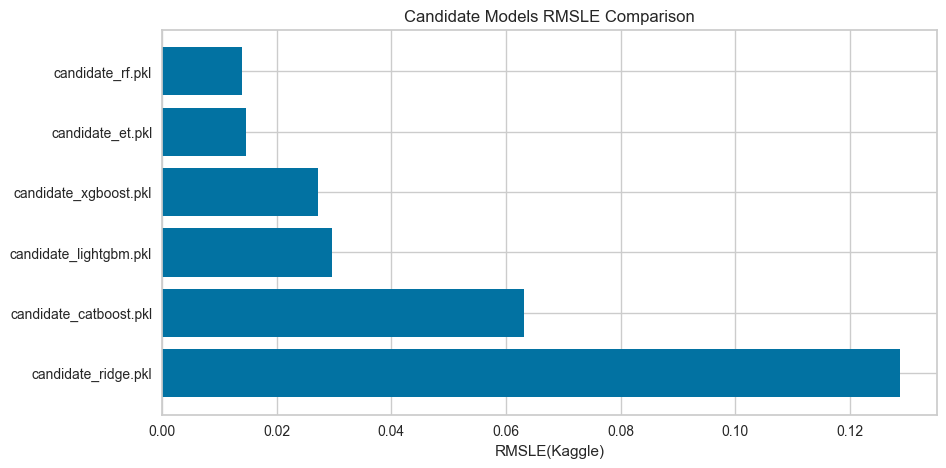

In [11]:
from pycaret.regression import predict_model

candidates = analyzer.list_candidate_models(verbose=False)

for fname in candidates:
    model = analyzer.load_candidate_model(fname)
    pred_df = predict_model(model, data=analyzer.train_vectorized)
    print(fname, pred_df.head())

# 각 모델 RMSLE 다시 재계산해서 ranking
analyzer.evaluate_candidate_models()

# 그래프 저장
analyzer.plot_candidate_rmsles()

In [12]:
analyzer.plot_feature_importance()

AttributeError: 'MercariPyCaretAnalyzer9' object has no attribute 'plot_feature_importance'

In [13]:
# 시각화
import glob
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


def compute_rmsle(y_true, y_pred):
    import numpy as np

    # ⚠ y_true, y_pred가 log1p(price) 상태라면
    # 실제 RMSLE와는 다르지만, 모델 간 비교용으로는 일단 사용 가능
    return np.sqrt(
        np.mean((np.log1p(np.expm1(y_pred)) - np.log1p(np.expm1(y_true))) ** 2)
    )


def compare_saved_models_metrics(analyzer, models_dir="../models"):
    """
    ../models 폴더에서
      - candidate_*.pkl
      - mercari_best_latest.pkl
    만 로드해서
    train_vectorized 기준 메트릭 계산 후
    바 차트로 비교 + 이미지 저장
    """
    from datetime import datetime

    # 1) 후보 모델 파일 리스트 만들기
    candidate_files = glob.glob(os.path.join(models_dir, "candidate_*.pkl"))
    # best_latest_path = os.path.join(models_dir, "mercari_best_latest.pkl")
    model_files = []

    model_files.extend(candidate_files)
    # if os.path.exists(best_latest_path):
    #     model_files.append(best_latest_path)

    if not model_files:
        print("❌ candidate_* 또는 mercari_best_latest.pkl 이 없습니다.")
        return

    print("📂 사용 대상 모델 파일들:")
    for f in model_files:
        print("   -", f)

    # 2) 데이터 준비
    X = analyzer.train_vectorized
    y_true = analyzer.train["price"]  # log1p(price) 상태라면 그대로 사용

    rows = []

    # 3) 각 모델별 메트릭 계산
    for mf in model_files:
        name = os.path.basename(mf).replace(".pkl", "")  # 그래프에 표시될 이름
        print(f"\n▶ loading {name} ...")

        # ❗ 여기서 pycaret.load_model이 아니라, 저장된 pkl 그대로 joblib.load
        model = joblib.load(mf)

        # 혹시 모델이 아니라 이상한 객체면 skip
        if not hasattr(model, "predict"):
            print(f"⚠ {name}: predict 메서드가 없습니다. (모델 아님) → skip")
            continue

        preds = model.predict(X)

        r2 = r2_score(y_true, preds)
        rmse = mean_squared_error(y_true, preds) ** 0.5
        mae = mean_absolute_error(y_true, preds)

        try:
            rmsle_val = compute_rmsle(y_true, preds)
        except Exception as e:
            print(f"⚠ {name}: RMSLE 계산 중 오류 → {e}")
            rmsle_val = None

        rows.append(
            {
                "model": name,
                "R2": r2,
                "RMSE": rmse,
                "MAE": mae,
                "RMSLE": rmsle_val,
            }
        )

    if not rows:
        print("❌ 유효한 모델이 하나도 없습니다.")
        return

    df = pd.DataFrame(rows)
    print("\n=== Model Metrics ===")
    print(df)

    ts = datetime.now().strftime("%Y%m%d_%H%M%S")

    # (A) df 저장
    os.makedirs("../results", exist_ok=True)
    df_path = f"../results/{ts}_model_metrics.csv"
    df.to_csv(df_path, index=False, encoding="utf-8-sig")
    print(f"💾 metrics CSV 저장 완료: {df_path}")

    # (B) matplotlib 한글 처리
    plt.rcParams["font.family"] = "Malgun Gothic"  # 윈도우 기준
    plt.rcParams["axes.unicode_minus"] = False

    # 4) R2 기준 barplot + 저장
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x="model", y="R2")
    plt.title("pycaret 학습모델별 metrics 비교표")
    plt.xticks(rotation=45)
    plt.tight_layout()

    # 이미지 저장
    os.makedirs("../images", exist_ok=True)

    file_path = f"../images/{ts}_model_metrics.png"
    plt.savefig(file_path, dpi=200)
    plt.show()

    print(f"📁 그래프 저장 완료: {file_path}")

    return df


def compare_models_subplots(analyzer, df_metrics, save=True):
    """
    df_metrics: compare_saved_models_metrics(analyzer) 결과 DataFrame
    주요 metric 4개를 2x2 subplot으로 비교 + 라벨 + 저장
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    from datetime import datetime
    import os

    metrics = ["R2", "RMSE", "MAE", "RMSLE"]
    titles = [
        "R2 비교",
        "RMSE 비교",
        "MAE 비교",
        "RMSLE 비교",
    ]

    plt.rcParams["font.family"] = "Malgun Gothic"  # 한글 폰트
    plt.rcParams["axes.unicode_minus"] = False

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    for i, m in enumerate(metrics):
        ax = axes[i]
        sns.barplot(data=df_metrics, x="model", y=m, ax=ax)
        ax.set_title(titles[i])
        ax.tick_params(axis="x", rotation=45)

        # 숫자 라벨
        for idx, row in df_metrics.iterrows():
            val = row[m]
            if pd.isna(val):
                continue
            ax.text(
                idx,
                val + val * 0.01,
                f"{val:.4f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    plt.tight_layout()

    # 저장
    if save:
        os.makedirs("../images", exist_ok=True)
        ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        file_path = f"../images/{ts}_metrics_subplots.png"
        plt.savefig(file_path, dpi=200)
        print(f"📁 subplot 그래프 저장 완료: {file_path}")

    plt.show()

📂 사용 대상 모델 파일들:
   - ../models\candidate_catboost.pkl
   - ../models\candidate_et.pkl
   - ../models\candidate_lightgbm.pkl
   - ../models\candidate_rf.pkl
   - ../models\candidate_ridge.pkl
   - ../models\candidate_xgboost.pkl

▶ loading candidate_catboost ...

▶ loading candidate_et ...

▶ loading candidate_lightgbm ...

▶ loading candidate_rf ...

▶ loading candidate_ridge ...

▶ loading candidate_xgboost ...

=== Model Metrics ===
                model        R2      RMSE       MAE     RMSLE
0  candidate_catboost  0.992811  0.063222  0.029741  0.063222
1        candidate_et  0.999615  0.014622  0.001818  0.014622
2  candidate_lightgbm  0.998413  0.029704  0.015612  0.029704
3        candidate_rf  0.999653  0.013892  0.002772  0.013892
4     candidate_ridge  0.970178  0.128770  0.082687  0.128770
5   candidate_xgboost  0.997048  0.040516  0.027875  0.040516
💾 metrics CSV 저장 완료: ../results/20251209_102541_model_metrics.csv


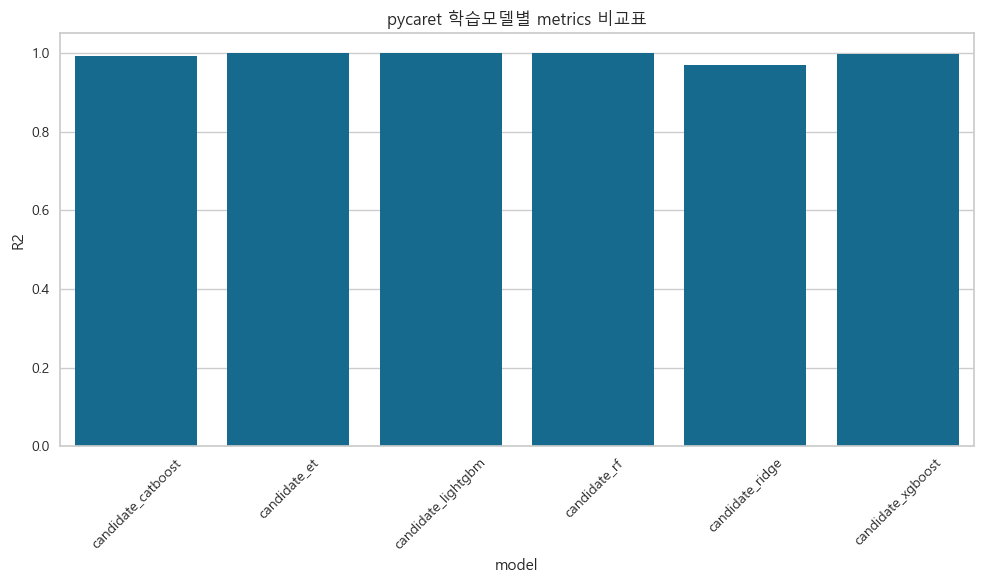

📁 그래프 저장 완료: ../images/20251209_102541_model_metrics.png
📁 subplot 그래프 저장 완료: ../images/20251209_102541_metrics_subplots.png


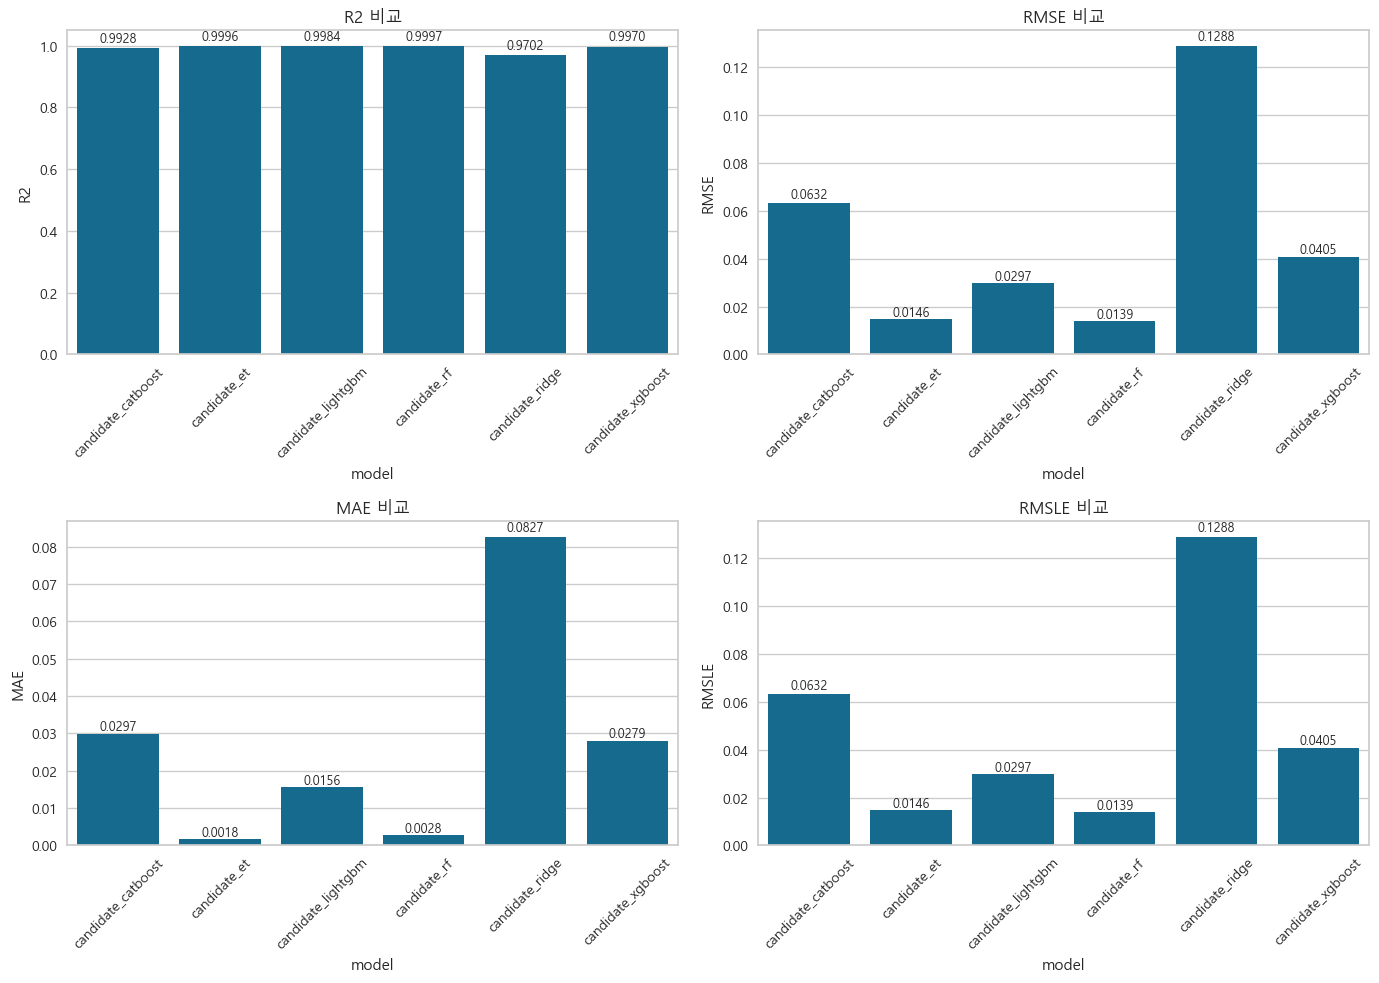

In [14]:
df_metrics = compare_saved_models_metrics(analyzer)
compare_models_subplots(analyzer, df_metrics)

In [15]:
# Full Data로 다시 학습하기
def train_full_best(
    analyzer,
    create_model_kwargs=None,
    save_meta_json=True,
):
    """
    Full data 재학습
    - 모델: ../models/
    - meta + metrics: ../results/
    """

    from pycaret.regression import create_model, finalize_model, save_model
    from datetime import datetime
    import time, os, json, threading, sys

    if not hasattr(analyzer, "best_model_name"):
        raise AttributeError("best_model_name 이 없습니다. find_best_model() 먼저!")

    best_name = analyzer.best_model_name
    print(f"\n🚀 FULL DATA 재학습 시작 (best_model={best_name})")

    # 시작 시간
    start_ts = datetime.now()
    start_time = time.time()
    print(f"⏱ Start: {start_ts}")

    if create_model_kwargs is None:
        create_model_kwargs = {}
    print(f"⚙ create_model params: {create_model_kwargs}")

    # ------------ Progress Thread -------------
    stop_progress = False

    def progress_timer():
        import time, sys

        while not stop_progress:
            elapsed = time.time() - start_time
            sys.stdout.write(f"\r⏳ FULL 학습 중...  {elapsed:.1f} sec")
            sys.stdout.flush()
            time.sleep(2)

    progress_thread = threading.Thread(target=progress_timer, daemon=True)
    progress_thread.start()
    # ------------------------------------------

    # (1) full 학습 + CV
    grid = create_model(best_name, **create_model_kwargs)
    full_model = finalize_model(grid)

    # 종료 시간
    end_ts = datetime.now()
    elapsed_sec = (end_ts - start_ts).total_seconds()
    elapsed_min = elapsed_sec / 60

    # progress stop
    stop_progress = True

    print(f"\n⏰ End: {end_ts}")
    print(f"🕒 Elapsed: {elapsed_sec:.1f} sec ({elapsed_min:.1f} min)")

    # (2) CV metrics 추출: PyCaret score_grid
    try:
        metric_df = grid.score_grid  # DataFrame
        metrics_dict = metric_df.loc["Mean"].to_dict()
    except:
        metrics_dict = {}

    # meta dict
    meta = {
        "model_name": best_name,
        "start_time": start_ts.isoformat(),
        "end_time": end_ts.isoformat(),
        "elapsed_sec": elapsed_sec,
        "elapsed_min": elapsed_min,
        "create_model_kwargs": create_model_kwargs,
        "cv_metrics": metrics_dict,  # 🌟 저장됨
    }

    # 모델 객체에 meta embed
    full_model.meta = meta

    # (3) 모델 저장
    os.makedirs("../models", exist_ok=True)
    fname = f"full_{best_name}_{start_ts.strftime('%Y%m%d_%H%M%S')}"
    save_model(full_model, os.path.join("../models", fname))
    print(f"💾 saved model: ../models/{fname}.pkl")

    # (4) meta + metrics를 ../results 에 저장 🌟
    if save_meta_json:
        os.makedirs("../results", exist_ok=True)
        meta_path = os.path.join("../results", f"{fname}_meta.json")
        with open(meta_path, "w", encoding="utf-8") as f:
            json.dump(meta, f, indent=4, ensure_ascii=False)
        print(f"📝 meta json saved: {meta_path}")

    # analyzer 내부 state
    analyzer.best_full_model = full_model
    analyzer.full_model_path = f"../models/{fname}.pkl"

    return full_model

In [16]:
# conda install -c conda-forge lightgbm-gpu 설치 후 아래 실행하기.. 우선 lightGBM 부터
# 베스트 모델 이름을 아래에 셋팅하기.
analyzer.best_model_name = "lightgbm"

full_lgbm = train_full_best(
    analyzer,
    create_model_kwargs={
        "gpu": True,  # GPU 사용 시
        "n_jobs": 4,
    },
)


🚀 FULL DATA 재학습 시작 (best_model=lightgbm)
⏱ Start: 2025-12-08 10:49:30.258120
⚙ create_model params: {'gpu': True, 'n_jobs': 4}
⏳ FULL 학습 중...  0.0 sec

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

⏳ FULL 학습 중...  6.2 sec

         MAE     MSE    RMSE      R2   RMSLE    MAPE
Fold                                                
0     0.0154  0.0011  0.0331  0.9980  0.0075  0.0051
1     0.0160  0.0012  0.0345  0.9979  0.0079  0.0053
2     0.0158  0.0010  0.0322  0.9981  0.0076  0.0053
Mean  0.0157  0.0011  0.0332  0.9980  0.0076  0.0052
Std   0.0003  0.0001  0.0010  0.0001  0.0002  0.0001
⏳ FULL 학습 중...  321.4 sec
⏰ End: 2025-12-08 10:54:52.079565
🕒 Elapsed: 321.8 sec (5.4 min)
Transformation Pipeline and Model Successfully Saved
💾 saved model: ../models/full_lightgbm_20251208_104930.pkl
📝 meta json saved: ../results\full_lightgbm_20251208_104930_meta.json


In [17]:
analyzer.best_full_model = full_lgbm
analyzer.predict_test(submission_file="full_lgbm_submission.csv")

📦 테스트 예측 시작...
💾 제출 파일 저장: ../results\20251208_105512_full_lgbm_submission.csv
   - 예측 가격 범위: $3.18 ~ $194.96, 평균: $20.28


,test_id,price
0,0,15.452477
1,1,15.452477
2,2,31.972426
3,3,15.452477
4,4,15.452477
...,...,...
693354,693354,15.452477
693355,693355,18.087635
693356,693356,15.452477
693357,693357,15.452477


In [28]:
# XGB 실행 for stacking
analyzer.best_model_name = "xgboost"

# full_xgb = train_full_best(
#     analyzer,
#     create_model_kwargs={
#         "use_gpu": True,
#         "tree_method": "gpu_hist",
#         "predictor": "gpu_predictor",
#         "n_jobs": 4,
#     }
# )

# cpu 버전일대
full_xgb = train_full_best(
    analyzer,
    create_model_kwargs={
        "n_jobs": 4,
        "tree_method": "hist",
    },
)
analyzer.best_full_model = full_xgb
analyzer.predict_test(submission_file="full_xgb_submission.csv")


🚀 FULL DATA 재학습 시작 (best_model=xgboost)
⏱ Start: 2025-12-08 17:37:38.221275
⚙ create_model params: {'n_jobs': 4, 'tree_method': 'hist'}
⏳ FULL 학습 중...  0.0 sec

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

⏳ FULL 학습 중...  8.4 sec

         MAE     MSE    RMSE      R2   RMSLE    MAPE
Fold                                                
0     0.0148  0.0013  0.0363  0.9976  0.0079  0.0048
1     0.0151  0.0015  0.0385  0.9973  0.0084  0.0048
2     0.0147  0.0012  0.0353  0.9978  0.0079  0.0047
Mean  0.0149  0.0013  0.0367  0.9976  0.0081  0.0048
Std   0.0002  0.0001  0.0013  0.0002  0.0002  0.0000
⏳ FULL 학습 중...  291.5 sec
⏰ End: 2025-12-08 17:42:30.177585
🕒 Elapsed: 292.0 sec (4.9 min)
Transformation Pipeline and Model Successfully Saved
💾 saved model: ../models/full_xgboost_20251208_173738.pkl
📝 meta json saved: ../results\full_xgboost_20251208_173738_meta.json
📦 테스트 예측 시작...
💾 제출 파일 저장: ../results\20251208_174419_full_xgb_submission.csv
   - 예측 가격 범위: $3.18 ~ $194.96, 평균: $20.28


,test_id,price
0,0,15.452477
1,1,15.452477
2,2,31.972426
3,3,15.452477
4,4,15.452477
...,...,...
693354,693354,15.452477
693355,693355,18.087635
693356,693356,15.452477
693357,693357,15.452477


In [19]:
# ExtraTrees 경우
analyzer.best_model_name = "et"

full_et = train_full_best(
    analyzer,
    create_model_kwargs={
        "n_estimators": 200,
        "max_depth": 15,
        "min_samples_leaf": 3,
        "n_jobs": 4,
    },
)
analyzer.best_full_model = full_et
# 제출 파일
analyzer.predict_test(submission_file="full_et_submission.csv")


🚀 FULL DATA 재학습 시작 (best_model=et)
⏱ Start: 2025-12-08 11:02:08.640201
⚙ create_model params: {'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 3, 'n_jobs': 4}
⏳ FULL 학습 중...  0.0 sec

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

⏳ FULL 학습 중...  6.3 sec

         MAE     MSE    RMSE      R2   RMSLE    MAPE
Fold                                                
0     0.0147  0.0013  0.0362  0.9976  0.0091  0.0051
1     0.0148  0.0015  0.0384  0.9974  0.0095  0.0052
2     0.0146  0.0013  0.0362  0.9976  0.0090  0.0051
Mean  0.0147  0.0014  0.0369  0.9975  0.0092  0.0051
Std   0.0001  0.0001  0.0010  0.0001  0.0002  0.0000
⏳ FULL 학습 중...  9516.5 sec
⏰ End: 2025-12-08 15:02:55.631000
🕒 Elapsed: 14447.0 sec (240.8 min)
Transformation Pipeline and Model Successfully Saved
💾 saved model: ../models/full_et_20251208_110208.pkl
📝 meta json saved: ../results\full_et_20251208_110208_meta.json
📦 테스트 예측 시작...
💾 제출 파일 저장: ../results\20251208_150315_full_et_submission.csv
   - 예측 가격 범위: $3.18 ~ $194.96, 평균: $20.28


,test_id,price
0,0,15.452477
1,1,15.452477
2,2,31.972426
3,3,15.452477
4,4,15.452477
...,...,...
693354,693354,15.452477
693355,693355,18.087635
693356,693356,15.452477
693357,693357,15.452477


In [20]:
# RandomForest 실행
analyzer.best_model_name = "rf"

full_rf = train_full_best(
    analyzer,
    create_model_kwargs={  # 스태킹용 BestOpt 설정
        "n_estimators": 400,
        "max_depth": 20,
        "min_samples_leaf": 3,
        "max_features": "sqrt",
        "n_jobs": -1,
    },
)
analyzer.best_full_model = full_rf
analyzer.predict_test(submission_file="full_rf_submission.csv")


🚀 FULL DATA 재학습 시작 (best_model=rf)
⏱ Start: 2025-12-08 15:03:16.728383
⚙ create_model params: {'n_estimators': 400, 'max_depth': 20, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'n_jobs': -1}
⏳ FULL 학습 중...  0.0 sec

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

⏳ FULL 학습 중...  6.1 sec

         MAE     MSE    RMSE      R2   RMSLE    MAPE
Fold                                                
0     0.2800  0.1611  0.4013  0.7095  0.1000  0.1012
1     0.2823  0.1631  0.4039  0.7075  0.1004  0.1017
2     0.2770  0.1576  0.3969  0.7161  0.0990  0.1002
Mean  0.2798  0.1606  0.4007  0.7110  0.0998  0.1010
Std   0.0022  0.0023  0.0029  0.0036  0.0006  0.0006
⏳ FULL 학습 중...  3242.1 sec
⏰ End: 2025-12-08 15:57:19.303563
🕒 Elapsed: 3242.6 sec (54.0 min)
Transformation Pipeline and Model Successfully Saved
💾 saved model: ../models/full_rf_20251208_150316.pkl
📝 meta json saved: ../results\full_rf_20251208_150316_meta.json
📦 테스트 예측 시작...
💾 제출 파일 저장: ../results\20251208_155741_full_rf_submission.csv
   - 예측 가격 범위: $3.18 ~ $194.96, 평균: $20.28


,test_id,price
0,0,15.452477
1,1,15.452477
2,2,31.972426
3,3,15.452477
4,4,15.452477
...,...,...
693354,693354,15.452477
693355,693355,18.087635
693356,693356,15.452477
693357,693357,15.452477


In [5]:
# 전체로 스태킹하기
def blend_full_latest_models(
    analyzer,
    models_dir="../models",
    results_dir="../results",
    optimize="RMSLE",
    fold=3,
    target_model_names=None,
):
    """
    1) ../models 안에서 full_*.pkl 스캔
       - full_{model_name}_{timestamp}.pkl 패턴 가정
       - model_name 별로 가장 최근 timestamp 1개만 사용
       - target_model_names로 필터링 가능 (기본: ['lightgbm','xgboost','et','rf'])

    2) 최신 full 모델들로 PyCaret blend_models 실행

    3) blend CV metrics, meta json, submission csv, 그래프 png 저장

    4) 반환: final_blend (finalize_model 된 앙상블)
    """
    import os, glob, json
    from datetime import datetime

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    from pycaret.regression import (
        load_model,
        blend_models,
        finalize_model,
        predict_model,
        pull,
    )

    os.makedirs(results_dir, exist_ok=True)

    # 0) 사용할 대상 모델 이름
    if target_model_names is None:
        target_model_names = ["lightgbm", "xgboost", "et", "rf"]

    print(f"🎯 대상 모델 타입: {target_model_names}")

    # 1) full_*.pkl 스캔
    pattern = os.path.join(models_dir, "full_*.pkl")
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f"❌ '{pattern}' 패턴에 맞는 full 모델이 없습니다.")

    # 2) model_name / timestamp 파싱해서 최신 것만 남기기
    #    파일명 예: full_lightgbm_20251207_133045.pkl
    latest_by_name = {}  # {model_name: (timestamp_str, base_name)}

    for f in files:
        base = os.path.basename(f)  # full_lightgbm_20251207_133045.pkl
        name_no_ext = os.path.splitext(base)[0]  # full_lightgbm_20251207_133045

        parts = name_no_ext.split("_", 2)
        # ['full','lightgbm','20251207_133045'] 형태를 기대
        if len(parts) < 3:
            print(f"⚠ 파일명 패턴이 예상과 다름, 스킵: {base}")
            continue

        _, model_name, ts_str = parts

        if model_name not in target_model_names:
            print(f"ℹ 대상 모델이 아니므로 스킵: {model_name} ({base})")
            continue

        # 문자열 비교로도 타임스탬프는 크기 비교 가능 (YYYYMMDD_HHMMSS)
        prev = latest_by_name.get(model_name)
        if (prev is None) or (ts_str > prev[0]):
            latest_by_name[model_name] = (ts_str, name_no_ext)

    if not latest_by_name:
        raise RuntimeError(
            "❌ 대상 모델 이름에 해당하는 full_* 최신 모델을 찾지 못했습니다."
        )

    print("\n🔎 선택된 최신 full 모델들:")
    for mn, (ts_str, base_name) in latest_by_name.items():
        print(f"  - {mn}: {base_name}.pkl (ts={ts_str})")

    # 3) 실제 모델 로드
    models = []
    model_names = []

    for mn, (_, base_name) in latest_by_name.items():
        try:
            m = load_model(os.path.join(models_dir, base_name))
            # pycaret.load_model는 경로/이름만 줘도 알아서 .pkl 붙이므로
            # 여기서는 base_name만 줘도 되는데, 헷갈림 방지 차원에서 둘 다 허용
            models.append(m)
            model_names.append(base_name)
            print(f"✅ 로드 완료: {base_name}")
        except Exception as e:
            print(f"❌ 모델 로드 실패: {base_name} - {e}")

    if len(models) < 2:
        raise RuntimeError("❌ 블렌딩하려면 최소 2개 이상의 full 모델이 필요합니다.")

    # 4) 블렌딩
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    print(
        f"\n🚀 Blending 시작 (models={model_names}, optimize={optimize}, fold={fold})"
    )

    stack = blend_models(
        estimator_list=models,
        fold=fold,
        optimize=optimize,  # RMSLE 기준 최적화
        # strategy / method 는 버전 호환성 위해 기본값(auto) 사용
    )

    final_blend = finalize_model(stack)
    print("✨ Blending 완료 & finalize_model 적용.")

    # 5) CV metrics 저장
    scores = pull()  # 마지막 PyCaret 결과 테이블
    print("\n📊 Blending CV Metrics:")
    print(scores)

    scores_csv = os.path.join(results_dir, f"{ts}_blend_scores.csv")
    scores.to_csv(scores_csv, index=False)
    print(f"💾 blend scores CSV 저장: {scores_csv}")

    # 6) meta json 저장 (어떤 모델로 블렌딩했는지 기록)
    meta = {
        "timestamp": ts,
        "optimize": optimize,
        "fold": fold,
        "models_dir": models_dir,
        "results_dir": results_dir,
        "used_models": model_names,
        "score_csv": scores_csv,
    }
    meta_path = os.path.join(results_dir, f"{ts}_blend_meta.json")
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)
    print(f"📝 meta json 저장: {meta_path}")

    # 7) 테스트 예측 + submission 생성
    print("\n📦 테스트 예측 & 제출 파일 생성...")
    pred = predict_model(final_blend, data=analyzer.test_vectorized)
    price_pred = np.expm1(pred["Label"])

    sub = pd.DataFrame(
        {
            "test_id": analyzer.test["test_id"],
            "price": price_pred,
        }
    )

    # 파일명에 어떤 모델이 들어갔는지 간단하게 표시
    short_models = "_".join(sorted(latest_by_name.keys()))
    sub_name = f"{ts}_blend_{short_models}.csv"
    sub_path = os.path.join(results_dir, sub_name)
    sub.to_csv(sub_path, index=False)
    print(f"💾 submission 저장: {sub_path}")
    print(
        f"   - 예측 가격 범위: ${price_pred.min():.2f} ~ "
        f"${price_pred.max():.2f}, 평균: ${price_pred.mean():.2f}"
    )

    # 8) 간단한 bar plot (예: R2 또는 RMSLE)
    metric_candidates = [
        c for c in ["R2", "RMSE", "RMSLE", "MAE"] if c in scores.columns
    ]
    if metric_candidates:
        metric = metric_candidates[0]  # 첫 번째 우선
        plt.figure(figsize=(8, 4))
        plt.bar(scores.index.astype(str), scores[metric])
        plt.title(f"Blending CV {metric}")
        plt.xlabel("Row")
        plt.ylabel(metric)
        plt.tight_layout()
        img_path = os.path.join(results_dir, f"{ts}_blend_{metric}.png")
        plt.savefig(img_path, dpi=150)
        plt.close()
        print(f"🖼 블렌딩 {metric} 플롯 저장: {img_path}")
    else:
        print("⚠ scores 테이블에 R2/RMSE/RMSLE/MAE가 없어 플롯은 생략합니다.")

    print("\n✅ blend_full_latest_models 완료.")
    return final_blend


# eof =====================================================================================================

In [ ]:
def predict_only_voting_ensemble(
    analyzer,
    target_model_names=["lightgbm", "xgboost", "et", "rf"],
    models_dir="../models",
    results_dir="../results",
    submission_prefix="blend",
):
    """
    - 최신 full_* 모델을 load
    - VotingRegressor로 blending
    - test 예측 + submission 저장
    - blend RMSLE 계산 후 반환
    """
    import os, re, json, numpy as np
    from sklearn.ensemble import VotingRegressor
    from datetime import datetime
    from pycaret.regression import load_model

    os.makedirs(results_dir, exist_ok=True)

    # --------------------------------------------------------
    # (A) load latest full models
    # --------------------------------------------------------
    def _latest(path, prefix):
        files = [f for f in os.listdir(path) if f.startswith(prefix)]
        if not files:
            return None
        files = sorted(files, key=lambda x: x.split("_")[-1])
        return files[-1]

    models = {}
    for name in target_model_names:
        prefix = f"full_{name}"
        fname = _latest(models_dir, prefix)
        if not fname:
            raise ValueError(f"full model not found: prefix={prefix}")
        print(f"▶ loading {fname} ...")
        models[name] = load_model(os.path.join(models_dir, fname.replace(".pkl", "")))

    # VotingRegressor input
    estimators = [(k, v) for k, v in models.items()]
    voting = VotingRegressor(estimators)

    # --------------------------------------------------------
    # (B) fit on training again (tiny overhead)
    # --------------------------------------------------------
    print("🔄 voting.fit on full train ...")
    voting.fit(analyzer.train_vectorized, analyzer.train["price"])

    # --------------------------------------------------------
    # (C) predict & metrics
    # --------------------------------------------------------
    y_pred_train = voting.predict(analyzer.train_vectorized)
    rmsle = np.sqrt(
        np.mean((np.log1p(y_pred_train) - np.log1p(analyzer.train["price"])) ** 2)
    )
    print(f"✨ blend RMSLE(train): {rmsle:.6f}")

    # --------------------------------------------------------
    # (D) test prediction
    # --------------------------------------------------------
    y_pred = voting.predict(analyzer.test_vectorized)
    pred_price = np.expm1(y_pred)
    submission = analyzer.test[["test_id"]].copy()
    submission["price"] = pred_price

    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_path = os.path.join(results_dir, f"{ts}_{submission_prefix}.csv")
    submission.to_csv(save_path, index=False)

    print(f"💾 saved: {save_path}")
    print(
        f"  - range ${pred_price.min():.2f} ~ ${pred_price.max():.2f}, mean ${pred_price.mean():.2f}"
    )

    return models, rmsle

In [3]:
def load_latest_full_models(
    models_dir="../models",
    target_model_names=None,  # ["lightgbm","xgboost","et","rf", ...]
):
    """
    ../models 안에서 full_{model_name}_{timestamp}.pkl 파일 중
    각 model_name마다 timestamp가 가장 큰(최근) 것만 골라서 load_model으로 로딩.

    return:
        dict { model_name : loaded_model }
    """
    import os, glob
    from pycaret.regression import load_model

    if target_model_names is None:
        target_model_names = ["lightgbm", "xgboost", "et", "rf"]

    pattern = os.path.join(models_dir, "full_*.pkl")
    files = sorted(glob.glob(pattern))

    if not files:
        raise FileNotFoundError(f"❌ '{pattern}' 경로에 full 모델이 없습니다.")

    # model_name별 가장 최신 timestamp 찾기
    latest = {}  # {model_name: (ts, base_name)}

    for f in files:
        base = os.path.basename(f)  # full_lightgbm_20251207_133045.pkl
        name_no_ext = os.path.splitext(base)[0]  # full_lightgbm_20251207_133045

        parts = name_no_ext.split("_", 2)  # ['full','lightgbm','20251207_133045']
        if len(parts) < 3:
            print(f"⚠ 스킵 (파일명 패턴 불일치): {base}")
            continue

        _, model_name, ts = parts

        if model_name not in target_model_names:
            continue

        prev = latest.get(model_name)
        if (prev is None) or (ts > prev[0]):
            latest[model_name] = (ts, name_no_ext)

    if not latest:
        raise RuntimeError(
            f"❌ target_model_names={target_model_names} 중 최신 full 모델을 찾지 못했습니다."
        )

    print("\n🔎 최신 full 모델 선택 결과:")
    results = {}
    for model_name, (ts, base_name) in latest.items():
        print(f"  - {model_name}: {base_name}.pkl (ts={ts})")
        print(f"▶ loading {base_name} ...")
        try:
            m = load_model(os.path.join(models_dir, base_name))
            results[model_name] = m
        except Exception as e:
            print(f"❌ 로드 실패: {base_name}: {e}")

    if len(results) < 2:
        print("⚠ 경고: 2개 미만 로드됨 (앙상블 의미 거의 없음)")

    return results


# eof =================================================================================================================

In [ ]:
def evaluate_all_models(
    analyzer,
    models,
    blend_rmsle,
    results_dir="../results",
):
    """
    개별 full 모델 + blend RMSLE 비교
    CSV + PNG + 콘솔
    """
    import os, json, numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from datetime import datetime

    os.makedirs(results_dir, exist_ok=True)
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")

    metrics = {}
    for name, model in models.items():
        p = model.predict(analyzer.train_vectorized)
        rmsle = np.sqrt(np.mean((np.log1p(p) - np.log1p(analyzer.train["price"])) ** 2))
        metrics[name] = rmsle

    metrics["blend"] = blend_rmsle
    df = pd.DataFrame.from_dict(metrics, orient="index", columns=["train_RMSLE"])
    df = df.sort_values("train_RMSLE")

    # CSV
    csv_path = os.path.join(results_dir, f"{ts}_model_train_metrics.csv")
    df.to_csv(csv_path)
    print(f"💾 saved metrics: {csv_path}")

    # Plot
    plt.figure(figsize=(8, 4))
    df["train_RMSLE"].plot(kind="bar")
    plt.ylabel("train RMSLE")
    plt.title("Full Models vs Blend")
    plt.tight_layout()
    png_path = os.path.join(results_dir, f"{ts}_model_train_metrics.png")
    plt.savefig(png_path, dpi=150)
    print(f"📊 saved plot: {png_path}")

    print("\n===== RMSLE ranking =====")
    print(df)

    return df

In [17]:
models, blend_rmsle = predict_only_voting_ensemble(analyzer)

df_compare = evaluate_all_models(analyzer, models, blend_rmsle)

▶ loading full_lightgbm_20251208_104930.pkl ...
Transformation Pipeline and Model Successfully Loaded
▶ loading full_xgboost_20251208_173738.pkl ...
Transformation Pipeline and Model Successfully Loaded
▶ loading full_et_20251208_110208.pkl ...
Transformation Pipeline and Model Successfully Loaded
▶ loading full_rf_20251208_150316.pkl ...
Transformation Pipeline and Model Successfully Loaded
🔄 voting.fit on full train ...
[LightGBM] [Warning] Unknown parameter: gpu
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Unknown parameter: gpu
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 201810
[LightGBM] [Info] Number of data points in the train set: 444498, number of used features: 837
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce GTX 1660 SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histo

KeyboardInterrupt: 

<Axes: >

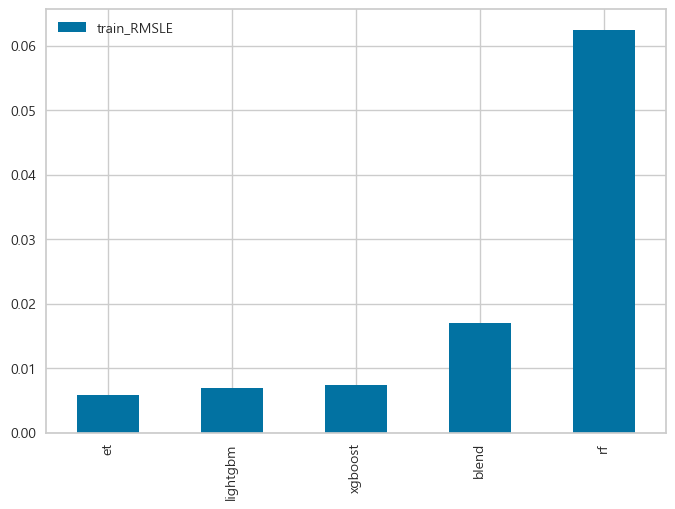

In [26]:
df_compare.plot(kind="bar")

In [27]:
df_compare.sort_values("train_RMSLE").style.highlight_min(color="lightgreen")

,train_RMSLE
et,0.005815
lightgbm,0.006937
xgboost,0.007467
blend,0.017078
rf,0.062477
